# Multivariate Structure and Prediction in the Communities and Crime Dataset

**Course:** Multivariate Data Analysis  

**Author:** Sidharth Saha, Shen-Ching Feng, Beckham Wee, Joe Wang

**Date:** 05/19/2026

## 1. Introduction

### Research Question

What multivariate community-level patterns are associated with above-median violent crime, and how well can those patterns be used to predict `HighViolentCrime`?

### Purpose

This report presents a multivariate analysis of the **Communities and Crime** dataset from the UCI Machine Learning Repository. The goal is to study aggregate community-level associations among socioeconomic, demographic, housing, family-structure, urbanization, and violent-crime variables. The analysis applies multiple multivariate methods covered in the course—including PCA, factor analysis, CCA, clustering, Gaussian mixture models, classification, and regularization—to uncover structure in the data and build predictive models.

### Motivation

Understanding the multivariate structure of community-level characteristics and their statistical association with crime rates is relevant for social science, public policy research, and applied statistics. This dataset offers a rich, high-dimensional setting that motivates the use of dimension-reduction, latent-variable modeling, and supervised classification methods.

### Outcome Variables and Their Role in the Analysis

This project uses two related crime outcome variables:

- **`ViolentCrimesPerPop`**: A normalized continuous measure of per-capita violent crime. This variable is used mainly for exploratory analysis and for comparing average crime levels across PCA scores, factor scores, clusters, and Gaussian mixture components.

- **`HighViolentCrime`**: A derived binary label indicating whether `ViolentCrimesPerPop` is above the sample median. This variable is used as the supervised classification target for logistic regression, LDA, and regularized classification models.

The unsupervised methods in this report—PCA, factor analysis, CCA, clustering, hierarchical clustering, and Gaussian mixture models—are fit using predictor variables rather than the crime outcomes. The outcomes are then used afterward to interpret whether the multivariate structures discovered by these methods are associated with higher or lower violent-crime levels.

### Scope

The project applies the following methods:

- Principal Component Analysis (PCA)
- Factor Analysis
- Canonical Correlation Analysis (CCA)
- K-Means and Hierarchical Clustering
- Gaussian Mixture Models (GMM)
- Logistic Regression, LDA, and Regularized Classification (Ridge, Lasso, Elastic Net)

### Ethical Framing

This dataset is observational and measured at the community level, so the analysis focuses on associations, prediction, and multivariate structure rather than causal claims. Because some variables describe sensitive demographic characteristics, results are interpreted as aggregate community-level patterns and not as claims about individual behavior or group identity.

---
## 2. Data Description and Preprocessing

### Source and Context

The Communities and Crime dataset combines data from three sources:

- **1990 U.S. Census** — socioeconomic, demographic, housing, and family-structure variables.
- **1990 Law Enforcement Management and Administrative Statistics (LEMAS)** — police-force and law-enforcement variables.
- **1995 FBI Uniform Crime Report (UCR)** — violent crime rates.

Each observation represents a U.S. community. The predictor space includes variables measuring income, poverty, education, employment, race/ethnicity composition, housing characteristics, family structure, population density, urbanization, immigration, and law enforcement.

### Preprocessing Already Performed

1. **Identifier columns removed** — non-predictive community identifiers were dropped.
2. **High-missingness variables dropped** — any variable with more than 20% missing values was removed from the dataset.
3. **Median imputation** — remaining numeric missing values were imputed with the column median.
4. **Binary outcome derived** — `HighViolentCrime` was created by thresholding `ViolentCrimesPerPop` at the sample median.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["LOKY_MAX_CPU_COUNT"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"

In [2]:
crime = pd.read_csv('datasets/communities_crime.csv')
df = crime.copy()
df.head()

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop,HighViolentCrime
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20,High
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67,High
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43,High
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12,Low
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03,Low


### Why Standardization Matters

The predictor variables are measured on different scales (e.g., percentages, counts, per-capita rates). Many multivariate methods—PCA, factor analysis, CCA, clustering, regularized regression—depend on covariance, correlation, or distance calculations. Without standardization, variables with larger numeric ranges would dominate. **All predictor variables should be standardized (zero mean, unit variance) before analysis.**

Table 2.1 summarizes the retained variables by thematic group. The “Representative Variables” column lists selected examples from each group rather than the full set of variables. Most predictors describe community-level socioeconomic status, education and employment, family structure, immigration and language, housing and residential stability, and urbanization. The dataset contains only one retained law-enforcement variable, `LemasPctOfficDrugUn`, likely because many original law-enforcement variables were removed during preprocessing due to missingness. `ViolentCrimesPerPop` is treated as the continuous outcome, while `HighViolentCrime` is the derived binary classification label.

In [3]:
df.columns.tolist()

['population',
 'householdsize',
 'racepctblack',
 'racePctWhite',
 'racePctAsian',
 'racePctHisp',
 'agePct12t21',
 'agePct12t29',
 'agePct16t24',
 'agePct65up',
 'numbUrban',
 'pctUrban',
 'medIncome',
 'pctWWage',
 'pctWFarmSelf',
 'pctWInvInc',
 'pctWSocSec',
 'pctWPubAsst',
 'pctWRetire',
 'medFamInc',
 'perCapInc',
 'whitePerCap',
 'blackPerCap',
 'indianPerCap',
 'AsianPerCap',
 'OtherPerCap',
 'HispPerCap',
 'NumUnderPov',
 'PctPopUnderPov',
 'PctLess9thGrade',
 'PctNotHSGrad',
 'PctBSorMore',
 'PctUnemployed',
 'PctEmploy',
 'PctEmplManu',
 'PctEmplProfServ',
 'PctOccupManu',
 'PctOccupMgmtProf',
 'MalePctDivorce',
 'MalePctNevMarr',
 'FemalePctDiv',
 'TotalPctDiv',
 'PersPerFam',
 'PctFam2Par',
 'PctKids2Par',
 'PctYoungKids2Par',
 'PctTeen2Par',
 'PctWorkMomYoungKids',
 'PctWorkMom',
 'NumIlleg',
 'PctIlleg',
 'NumImmig',
 'PctImmigRecent',
 'PctImmigRec5',
 'PctImmigRec8',
 'PctImmigRec10',
 'PctRecentImmig',
 'PctRecImmig5',
 'PctRecImmig8',
 'PctRecImmig10',
 'PctSpeakEng

In [4]:
variable_groups = {
    "Population / Urbanization": [
        "population", "householdsize", "numbUrban", "pctUrban",
        "LandArea", "PopDens", "PctUsePubTrans"
    ],

    "Demographic Composition": [
        "racepctblack", "racePctWhite", "racePctAsian", "racePctHisp",
        "agePct12t21", "agePct12t29", "agePct16t24", "agePct65up"
    ],

    "Income / Poverty / Public Assistance": [
        "medIncome", "medFamInc", "perCapInc",
        "whitePerCap", "blackPerCap", "indianPerCap", "AsianPerCap",
        "OtherPerCap", "HispPerCap",
        "NumUnderPov", "PctPopUnderPov",
        "pctWWage", "pctWFarmSelf", "pctWInvInc",
        "pctWSocSec", "pctWPubAsst", "pctWRetire"
    ],

    "Education / Employment / Occupation": [
        "PctLess9thGrade", "PctNotHSGrad", "PctBSorMore",
        "PctUnemployed", "PctEmploy",
        "PctEmplManu", "PctEmplProfServ",
        "PctOccupManu", "PctOccupMgmtProf"
    ],

    "Family Structure": [
        "MalePctDivorce", "MalePctNevMarr", "FemalePctDiv", "TotalPctDiv",
        "PersPerFam", "PctFam2Par", "PctKids2Par",
        "PctYoungKids2Par", "PctTeen2Par",
        "PctWorkMomYoungKids", "PctWorkMom",
        "NumIlleg", "PctIlleg"
    ],

    "Immigration / Language": [
        "NumImmig", "PctImmigRecent", "PctImmigRec5",
        "PctImmigRec8", "PctImmigRec10",
        "PctRecentImmig", "PctRecImmig5",
        "PctRecImmig8", "PctRecImmig10",
        "PctSpeakEnglOnly", "PctNotSpeakEnglWell",
        "PctForeignBorn"
    ],

    "Housing / Residential Stability": [
        "PctLargHouseFam", "PctLargHouseOccup",
        "PersPerOccupHous", "PersPerOwnOccHous", "PersPerRentOccHous",
        "PctPersOwnOccup", "PctPersDenseHous",
        "PctHousLess3BR", "MedNumBR",
        "HousVacant", "PctHousOccup", "PctHousOwnOcc",
        "PctVacantBoarded", "PctVacMore6Mos",
        "MedYrHousBuilt", "PctHousNoPhone", "PctWOFullPlumb",
        "OwnOccLowQuart", "OwnOccMedVal", "OwnOccHiQuart",
        "RentLowQ", "RentMedian", "RentHighQ",
        "MedRent", "MedRentPctHousInc",
        "MedOwnCostPctInc", "MedOwnCostPctIncNoMtg",
        "PctBornSameState", "PctSameHouse85",
        "PctSameCity85", "PctSameState85"
    ],

    "Shelter / Homelessness": [
        "NumInShelters", "NumStreet"
    ],

    "Law Enforcement": [
        "LemasPctOfficDrugUn"
    ],

    "Outcomes": [
        "ViolentCrimesPerPop", "HighViolentCrime"
    ]
}

variable_group_summary = pd.DataFrame([
    {
        "Variable Group": group,
        "Number of Variables": len(cols),
        "Representative Variables": ", ".join(cols[:5]) + ("..." if len(cols) > 5 else "")
    }
    for group, cols in variable_groups.items()
])

pd.set_option("display.max_colwidth", None)
variable_group_summary



,Variable Group,Number of Variables,Representative Variables
0,Population / Urbanization,7,"population, householdsize, numbUrban, pctUrban, LandArea..."
1,Demographic Composition,8,"racepctblack, racePctWhite, racePctAsian, racePctHisp, agePct12t21..."
2,Income / Poverty / Public Assistance,17,"medIncome, medFamInc, perCapInc, whitePerCap, blackPerCap..."
3,Education / Employment / Occupation,9,"PctLess9thGrade, PctNotHSGrad, PctBSorMore, PctUnemployed, PctEmploy..."
4,Family Structure,13,"MalePctDivorce, MalePctNevMarr, FemalePctDiv, TotalPctDiv, PersPerFam..."
5,Immigration / Language,12,"NumImmig, PctImmigRecent, PctImmigRec5, PctImmigRec8, PctImmigRec10..."
6,Housing / Residential Stability,31,"PctLargHouseFam, PctLargHouseOccup, PersPerOccupHous, PersPerOwnOccHous, PersPerRentOccHous..."
7,Shelter / Homelessness,2,"NumInShelters, NumStreet"
8,Law Enforcement,1,LemasPctOfficDrugUn
9,Outcomes,2,"ViolentCrimesPerPop, HighViolentCrime"


Table 2.2 confirms that the retained analysis dataset contains no remaining missing values after preprocessing. Variables with more than 20% missingness were removed before this stage, and remaining numeric missing values were median-imputed. As a result, all retained variables have a missing count of zero in the final modeling dataset.

In [5]:
missingness_report_table = pd.DataFrame({
    "Missingness Category": [
        "Variables with no missing values",
        "Variables with some missing values",
        "Variables with >20% missingness in retained dataset"
    ],
    "Number of Variables": [
        (df.isna().sum() == 0).sum(),
        (df.isna().sum() > 0).sum(),
        ((df.isna().mean() * 100) > 20).sum()
    ]
})

missingness_report_table

,Missingness Category,Number of Variables
0,Variables with no missing values,102
1,Variables with some missing values,0
2,Variables with >20% missingness in retained dataset,0


Table 2.3 reports the class balance for `HighViolentCrime`. Because the binary label was created using the sample median of `ViolentCrimesPerPop`, the two classes are approximately balanced: 993 communities are classified as high violent-crime communities and 1001 are classified as low violent-crime communities. This balanced split means that accuracy is more interpretable than it would be in a highly imbalanced setting, although later classification results should still report sensitivity, specificity, and ROC-AUC.

In [6]:
class_balance = (
    df["HighViolentCrime"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

class_balance["Proportion"] = (
    class_balance["Count"] / class_balance["Count"].sum()
).round(3)

class_balance

,Class,Count,Proportion
0,Low,1001,0.502
1,High,993,0.498


Figure 2.1 shows the distribution of `ViolentCrimesPerPop`, the continuous violent-crime outcome. The distribution is right-skewed, with many communities having relatively low values and a smaller number of communities having much higher values near the upper end of the normalized scale. The sample skewness is approximately 1.52, confirming a positive right tail. The dashed vertical line marks the sample median, approximately 0.150, which is used to define the binary outcome `HighViolentCrime`.

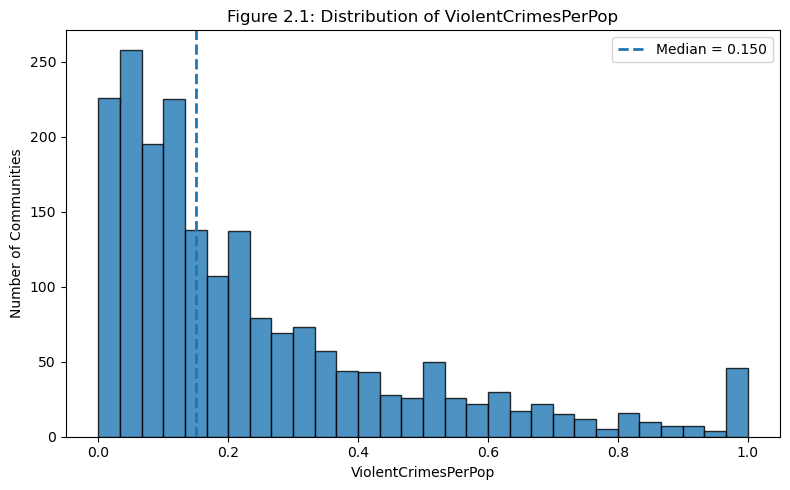

In [7]:
violent_crime = df["ViolentCrimesPerPop"]

median_crime = violent_crime.median()

plt.figure(figsize=(8, 5))
plt.hist(violent_crime, bins=30, edgecolor="black", alpha=0.8)
plt.axvline(median_crime, linestyle="--", linewidth=2, label=f"Median = {median_crime:.3f}")

plt.title("Figure 2.1: Distribution of ViolentCrimesPerPop")
plt.xlabel("ViolentCrimesPerPop")
plt.ylabel("Number of Communities")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
violent_crime_skewness = violent_crime.skew()
violent_crime_skewness

np.float64(1.522598485536617)

---
## 3. Exploratory Data Analysis

### Purpose

Understand the distributions, correlations, and broad associations among the variables before applying multivariate methods. EDA provides context for later analyses and helps identify potential issues (outliers, non-linearity, strong collinearity).

### Analyses

#### 3.1 Group-Level Summary Statistics

Table 3.1 computes group-level averages of the means, standard deviations, medians, and ranges for the normalized predictor variables within each thematic group. This provides a broad baseline summary of variable magnitude and spread across the retained predictor groups.

In [9]:
group_level_summary = []

for group, cols in variable_groups.items():
    group_data = df[cols]

    group_level_summary.append({
        "Variable Group": group,
        "Number of Variables": len(cols),
        "Average Mean": group_data.mean(numeric_only=True).mean(),
        "Average Std. Dev.": group_data.std(numeric_only=True).mean(),
        "Average Median": group_data.median(numeric_only=True).mean(),
        "Overall Min": group_data.min(numeric_only=True).min(),
        "Overall Max": group_data.max(numeric_only=True).max()
    })

group_level_summary = pd.DataFrame(group_level_summary)

group_level_summary.round(3)

,Variable Group,Number of Variables,Average Mean,Average Std. Dev.,Average Median,Overall Min,Overall Max
0,Population / Urbanization,7,0.249,0.201,0.253,0.0,1.0
1,Demographic Composition,8,0.364,0.198,0.326,0.0,1.0
2,Income / Poverty / Public Assistance,17,0.348,0.187,0.312,0.0,1.0
3,Education / Employment / Occupation,9,0.399,0.196,0.369,0.0,1.0
4,Family Structure,13,0.474,0.182,0.473,0.0,1.0
5,Immigration / Language,12,0.285,0.211,0.239,0.0,1.0
6,Housing / Residential Stability,31,0.404,0.202,0.382,0.0,1.0
7,Shelter / Homelessness,2,0.026,0.102,0.000,0.0,1.0
8,Law Enforcement,1,0.094,0.240,0.000,0.0,1.0
9,Outcomes,2,0.238,0.233,0.150,0.0,1.0


#### 3.2 Distribution of the Violent Crime Outcome

Table 3.2 summarizes the continuous outcome `ViolentCrimesPerPop`. The mean value is 0.238, while the median is lower at 0.150, indicating that the distribution is right-skewed. This is also confirmed by the skewness value of 1.523 and by the boxplot, which shows several communities with unusually high violent-crime values relative to the rest of the sample.

The log-transformed histogram was used as a diagnostic check for skewness. Although the transformation compresses the upper tail, the main supervised analysis uses the binary outcome `HighViolentCrime`, so the continuous outcome is not transformed for the main classification models.

In [10]:
violent_crime = df["ViolentCrimesPerPop"]

crime_summary = pd.DataFrame({
    "Mean": [violent_crime.mean()],
    "Std. Dev.": [violent_crime.std()],
    "Median": [violent_crime.median()],
    "Min": [violent_crime.min()],
    "Max": [violent_crime.max()],
    "Skewness": [violent_crime.skew()]
})

crime_summary.round(3)

,Mean,Std. Dev.,Median,Min,Max,Skewness
0,0.238,0.233,0.15,0.0,1.0,1.523


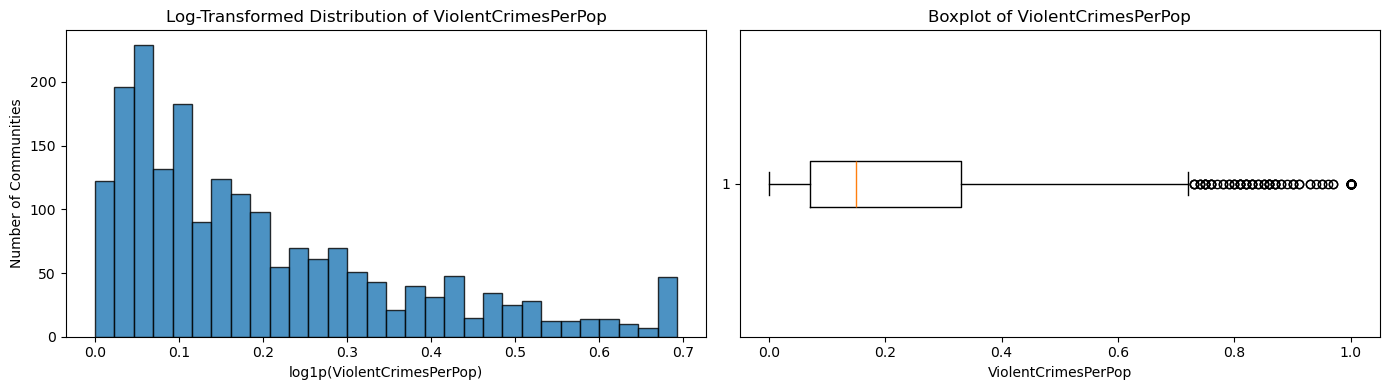

In [11]:
violent_crime = df["ViolentCrimesPerPop"]
violent_crime_log = np.log1p(violent_crime)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Log-transformed histogram
axes[0].hist(violent_crime_log, bins=30, edgecolor="black", alpha=0.8)
axes[0].set_title("Log-Transformed Distribution of ViolentCrimesPerPop")
axes[0].set_xlabel("log1p(ViolentCrimesPerPop)")
axes[0].set_ylabel("Number of Communities")

# Boxplot of original outcome
axes[1].boxplot(violent_crime, vert=False)
axes[1].set_title("Boxplot of ViolentCrimesPerPop")
axes[1].set_xlabel("ViolentCrimesPerPop")

plt.tight_layout()
plt.show()

#### 3.3 Correlation Heatmap

Figure 3.3 shows the correlation structure for a representative subset of variables from the major thematic groups. The full predictor set is too large for a readable heatmap, so selected variables were chosen to cover the main categories in Table 2.1, including population, demographic composition, income, education, family structure, immigration/language, housing, and law enforcement.

The heatmap reveals clear blocks of correlated predictors, especially among income, poverty, education, family-structure, and housing variables. This multicollinearity motivates the use of PCA and factor analysis for dimension reduction, CCA for relationships between variable blocks, and regularized models for more stable prediction. `ViolentCrimesPerPop` is included only as a reference outcome.

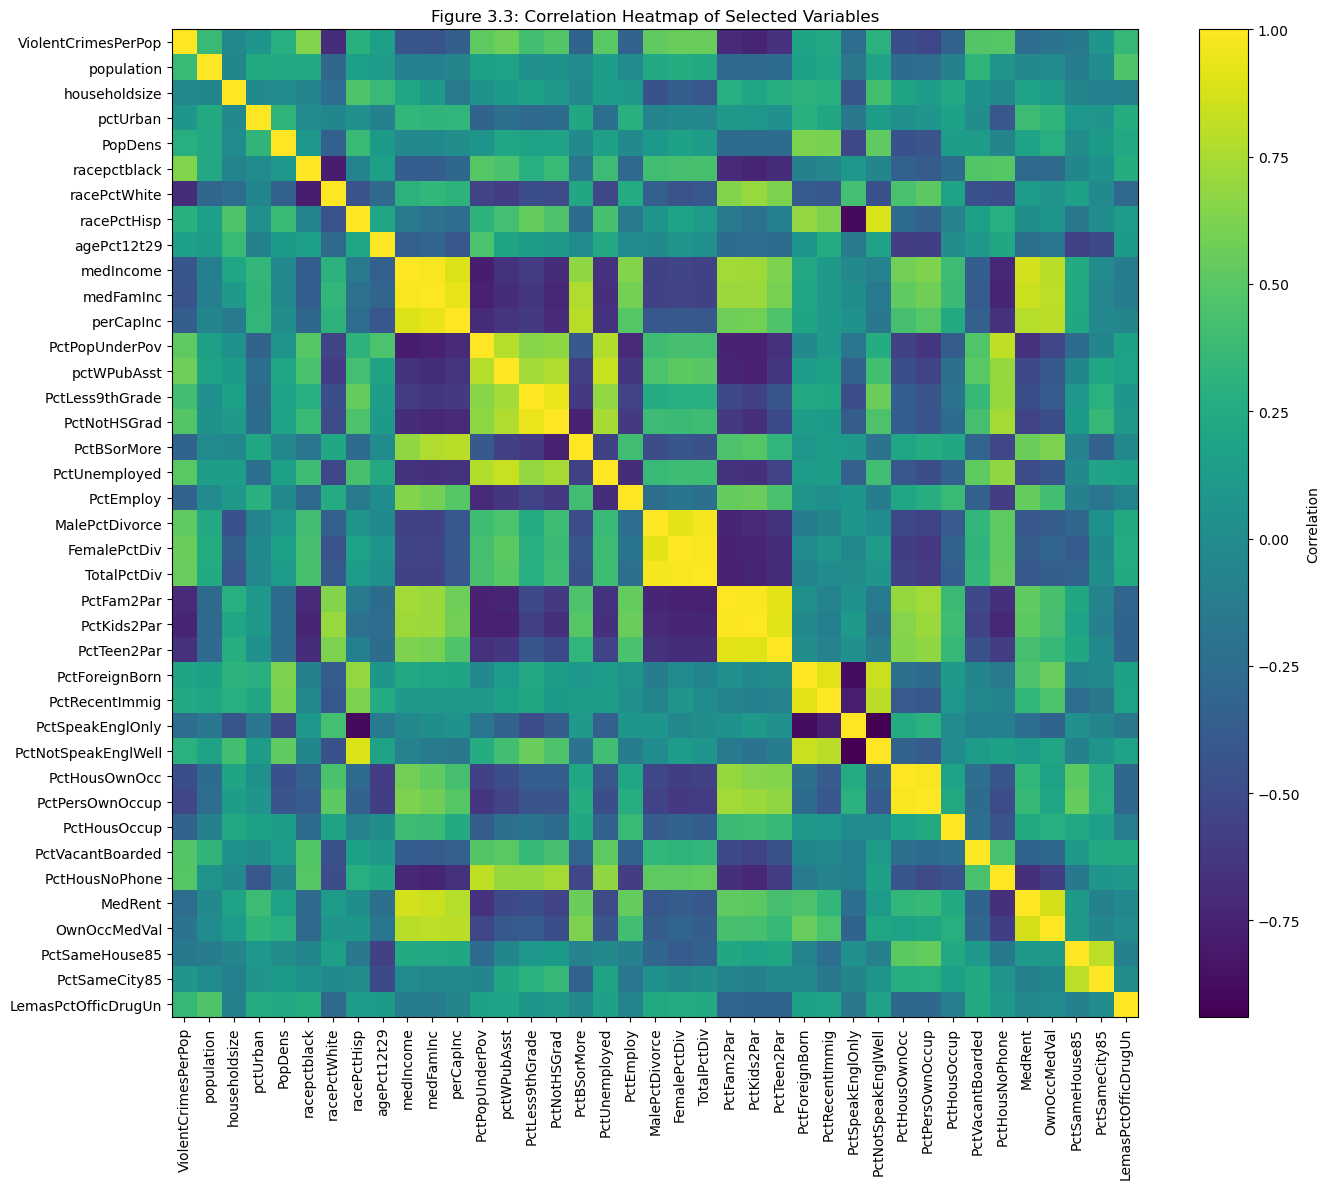

In [12]:
# Representative variables for readable correlation heatmap
heatmap_vars = [
    # Outcome
    "ViolentCrimesPerPop",

    # Population / urbanization
    "population", "householdsize", "pctUrban", "PopDens",

    # Demographic composition
    "racepctblack", "racePctWhite", "racePctHisp", "agePct12t29",

    # Income / poverty
    "medIncome", "medFamInc", "perCapInc", "PctPopUnderPov", "pctWPubAsst",

    # Education / employment
    "PctLess9thGrade", "PctNotHSGrad", "PctBSorMore",
    "PctUnemployed", "PctEmploy",

    # Family structure
    "MalePctDivorce", "FemalePctDiv", "TotalPctDiv",
    "PctFam2Par", "PctKids2Par", "PctTeen2Par",

    # Immigration / language
    "PctForeignBorn", "PctRecentImmig",
    "PctSpeakEnglOnly", "PctNotSpeakEnglWell",

    # Housing / residential stability
    "PctHousOwnOcc", "PctPersOwnOccup", "PctHousOccup",
    "PctVacantBoarded", "PctHousNoPhone",
    "MedRent", "OwnOccMedVal",
    "PctSameHouse85", "PctSameCity85",

    # Law enforcement
    "LemasPctOfficDrugUn"
]

# Keep only variables that exist in the dataframe
heatmap_vars = [col for col in heatmap_vars if col in df.columns]

corr_matrix = df[heatmap_vars].corr()

plt.figure(figsize=(14, 12))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Figure 3.3: Correlation Heatmap of Selected Variables")
plt.tight_layout()
plt.show()

#### 3.4 Boxplots: Low vs. High Violent-Crime Communities

Figure 3.4 compares selected normalized predictor variables between low and high violent-crime communities. High violent-crime communities tend to have lower median household income, lower owner-occupied housing, lower percentages of children in two-parent families, and lower bachelor’s degree attainment. They also tend to have higher poverty rates and somewhat higher population density. 

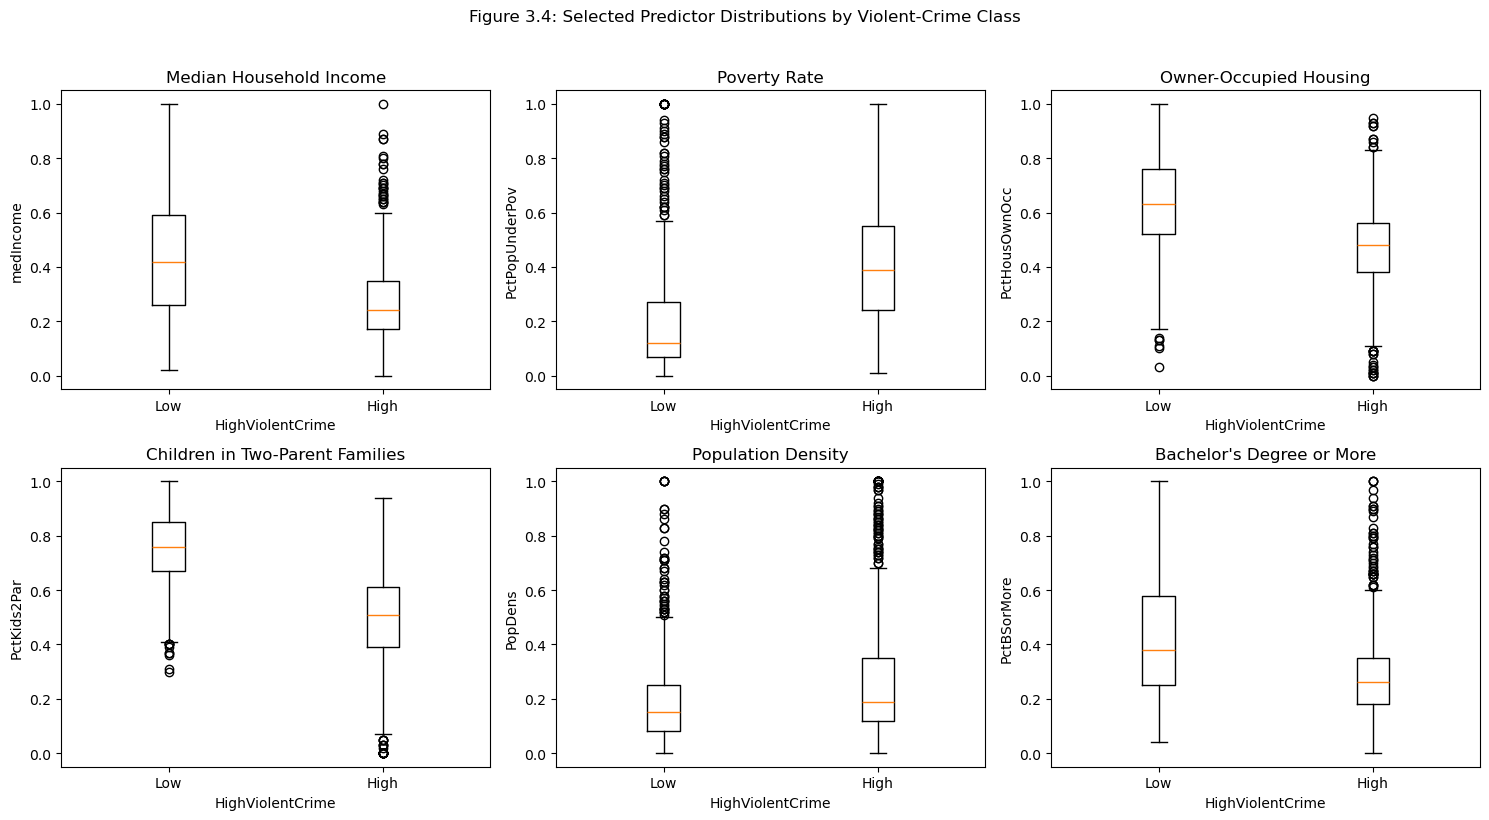

In [13]:
# Representative variables for low vs. high violent-crime comparison
boxplot_vars = {
    "medIncome": "Median Household Income",
    "PctPopUnderPov": "Poverty Rate",
    "PctHousOwnOcc": "Owner-Occupied Housing",
    "PctKids2Par": "Children in Two-Parent Families",
    "PopDens": "Population Density",
    "PctBSorMore": "Bachelor's Degree or More"
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (var, label) in zip(axes, boxplot_vars.items()):
    low_values = df[df["HighViolentCrime"] == "Low"][var]
    high_values = df[df["HighViolentCrime"] == "High"][var]
    
    ax.boxplot([low_values, high_values], tick_labels=["Low", "High"])
    ax.set_title(label)
    ax.set_xlabel("HighViolentCrime")
    ax.set_ylabel(var)

plt.suptitle("Figure 3.4: Selected Predictor Distributions by Violent-Crime Class", y=1.02)
plt.tight_layout()
plt.show()

## 4. PCA: Dimension Reduction of the Full Predictor Space

### 4.1 PCA Workflow and Setup

PCA is used to summarize the high-dimensional predictor space into orthogonal components that capture major directions of variation. Following the course workflow, the PCA analysis proceeds in five steps: data diagnosis, preprocessing choice, PC-count selection, interpretation through loadings and scores, and robustness/limitations.

The PCA is fit only on the predictor variables, excluding `ViolentCrimesPerPop` and `HighViolentCrime`. Although the retained variables are normalized to the 0–1 scale, they do not have equal variance, so correlation PCA is used by standardizing each predictor to mean 0 and standard deviation 1 before fitting PCA.

In [14]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Define outcome columns
outcome_cols = ["ViolentCrimesPerPop", "HighViolentCrime"]

# Predictor matrix only
X = df.drop(columns=outcome_cols)

# Standardize predictors for correlation PCA
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Quick checks
pca_setup_summary = pd.DataFrame({
    "Object": ["Original predictor matrix", "Standardized predictor matrix"],
    "Rows": [X.shape[0], X_scaled.shape[0]],
    "Columns": [X.shape[1], X_scaled.shape[1]],
    "Mean Check": [round(X.mean().mean(), 3), round(X_scaled.mean().mean(), 3)],
    "Std. Dev. Check": [round(X.std().mean(), 3), round(X_scaled.std().mean(), 3)]
})

pca_setup_summary

,Object,Rows,Columns,Mean Check,Std. Dev. Check
0,Original predictor matrix,1994,100,0.364,0.196
1,Standardized predictor matrix,1994,100,-0.000,1.000


The PCA setup table confirms that the analysis uses 100 predictor variables after excluding `ViolentCrimesPerPop` and `HighViolentCrime`. Although the original predictors are normalized, their average standard deviation is only 0.196, meaning they do not have equal variance. After standardization, the predictors have approximately mean 0 and standard deviation 1, so the PCA is fit as correlation PCA.

### 4.2 Step 1: Data Diagnosis

Before fitting PCA, the dataset was checked for missingness, outcome distribution, and correlation structure. Table 2.2 confirms that the retained modeling dataset contains no remaining missing values after preprocessing. Figure 3.3 shows strong blocks of correlated predictors, especially among income, poverty, education, family-structure, and housing variables. This correlation structure supports the use of PCA because the predictors contain shared multivariate variation that can be summarized through lower-dimensional components.

### 4.3 Step 2: Preprocessing Choice — Correlation PCA

PCA can be fit either on the covariance matrix or the correlation matrix. Because the predictors represent different types of community characteristics and still have unequal variances after normalization, this analysis uses correlation PCA. This means each predictor is standardized before PCA so that the components reflect shared correlation structure rather than differences in variable spread.

The standardized predictor matrix from Section 4.1 is used for the PCA fit.

In [15]:
from sklearn.decomposition import PCA

pca = PCA()
pca_scores = pca.fit_transform(X_scaled)

pca_scores_df = pd.DataFrame(
    pca_scores,
    columns=[f"PC{i+1}" for i in range(pca_scores.shape[1])],
    index=df.index
)

explained_variance = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = explained_variance_ratio.cumsum()

pca_fit_summary = pd.DataFrame({
    "Number of Observations": [X_scaled.shape[0]],
    "Number of Predictors": [X_scaled.shape[1]],
    "Number of PCs Computed": [pca_scores_df.shape[1]],
    "Total Variance Explained": [round(explained_variance_ratio.sum(), 3)]
})

pca_fit_summary

,Number of Observations,Number of Predictors,Number of PCs Computed,Total Variance Explained
0,1994,100,100,1.0


The PCA fit uses 100 standardized predictor variables after excluding `ViolentCrimesPerPop` and `HighViolentCrime`. Because all 100 PCs are computed, the total variance explained across the full set of components is 1.0, as expected. This confirms that the PCA model was fit correctly on the standardized predictor matrix.

### 4.4 Step 3: Choosing the Number of PCs

Figure 4.1 compares several criteria for choosing the number of principal components. The scree plot shows a steep decline in eigenvalues for the first several PCs, followed by a flatter region where additional components contribute less variance. The Kaiser rule retains PCs with eigenvalues greater than 1, while parallel analysis compares the observed eigenvalues to eigenvalues generated from random noise data of the same size.

These criteria do not need to give the same answer. The first few PCs are emphasized for interpretation because they explain the largest shares of variance and are most interpretable. A larger set of PCs may be retained for downstream clustering, GMM, and classification depending on the cumulative-variance and parallel-analysis results.

Figure 4.1 compares several criteria for choosing the number of PCs. The scree plot shows a steep decline in eigenvalues for the first several components, followed by a flatter region. The Kaiser rule retains 14 PCs, while parallel analysis suggests retaining 13 PCs because those observed eigenvalues exceed the random-data benchmark. The 80% cumulative-variance criterion requires 11 PCs. Taken together, these criteria suggest that roughly 11–14 PCs capture meaningful structure for downstream analysis, while the first four PCs are emphasized for interpretation because they explain the largest individual shares of variance.

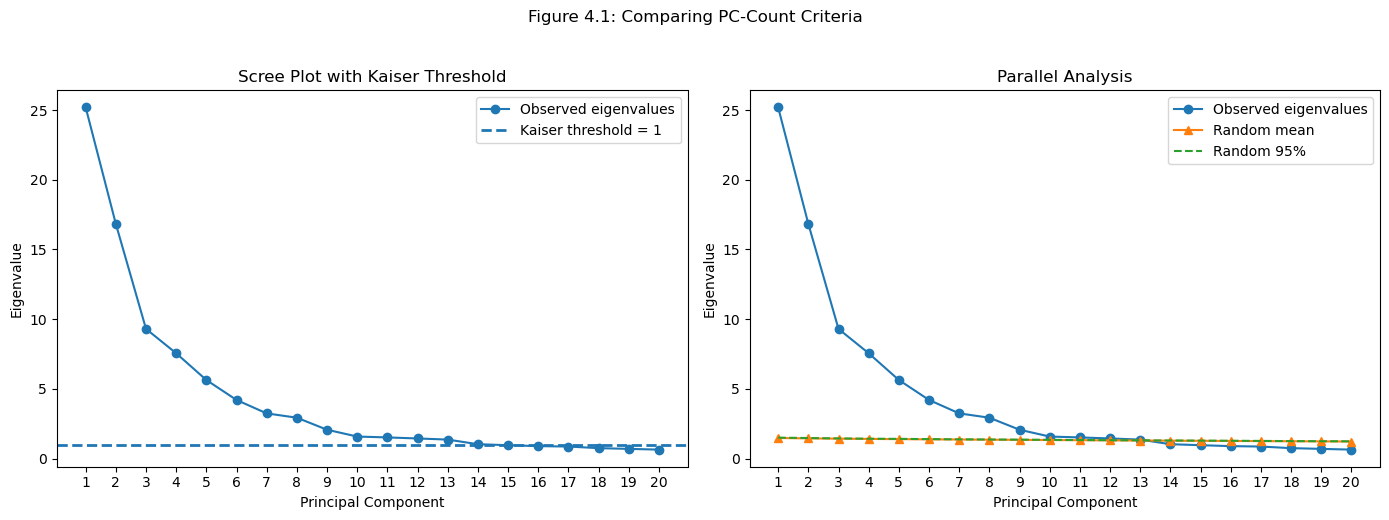

,Criterion,Number of PCs Suggested
0,80% cumulative variance,11
1,Kaiser rule: eigenvalue > 1,14
2,Parallel analysis: observed > random mean,13
3,Parallel analysis: observed > random 95%,13


In [16]:

# Observed PCA eigenvalues
observed_eigenvalues = explained_variance

# Kaiser rule
kaiser_pcs = (observed_eigenvalues > 1).sum()

# 80% cumulative variance rule
pcs_for_80 = (cumulative_variance < 0.80).sum() + 1

# Parallel analysis setup
n_simulations = 100
n_obs, n_vars = X_scaled.shape

random_eigenvalues = np.zeros((n_simulations, n_vars))

for i in range(n_simulations):
    random_data = np.random.normal(size=(n_obs, n_vars))
    random_pca = PCA().fit(random_data)
    random_eigenvalues[i, :] = random_pca.explained_variance_

random_mean = random_eigenvalues.mean(axis=0)
random_95 = np.percentile(random_eigenvalues, 95, axis=0)

# Parallel analysis rule
parallel_mean_pcs = (observed_eigenvalues > random_mean).sum()
parallel_95_pcs = (observed_eigenvalues > random_95).sum()

# Display first 20 PCs in plots
max_pc_plot = 20
pc_numbers = np.arange(1, max_pc_plot + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot with Kaiser threshold
axes[0].plot(
    pc_numbers,
    observed_eigenvalues[:max_pc_plot],
    marker="o",
    label="Observed eigenvalues"
)

axes[0].axhline(
    y=1,
    linestyle="--",
    linewidth=2,
    label="Kaiser threshold = 1"
)

axes[0].set_title("Scree Plot with Kaiser Threshold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_xticks(pc_numbers)
axes[0].legend()

# Parallel analysis plot
axes[1].plot(
    pc_numbers,
    observed_eigenvalues[:max_pc_plot],
    marker="o",
    label="Observed eigenvalues"
)

axes[1].plot(
    pc_numbers,
    random_mean[:max_pc_plot],
    marker="^",
    label="Random mean"
)

axes[1].plot(
    pc_numbers,
    random_95[:max_pc_plot],
    linestyle="--",
    label="Random 95%"
)

axes[1].set_title("Parallel Analysis")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Eigenvalue")
axes[1].set_xticks(pc_numbers)
axes[1].legend()

plt.suptitle("Figure 4.1: Comparing PC-Count Criteria", y=1.03)
plt.tight_layout()
plt.show()

pc_count_summary = pd.DataFrame({
    "Criterion": [
        "80% cumulative variance",
        "Kaiser rule: eigenvalue > 1",
        "Parallel analysis: observed > random mean",
        "Parallel analysis: observed > random 95%"
    ],
    "Number of PCs Suggested": [
        pcs_for_80,
        kaiser_pcs,
        parallel_mean_pcs,
        parallel_95_pcs
    ]
})

pc_count_summary

### 4.5 Step 4: Interpreting PC Loadings

PC loadings show which original variables contribute most strongly to each principal component. Table 4.2 reports the ten highest-magnitude loadings for the first four PCs. Although the PC-count criteria suggest retaining roughly 11–14 PCs for downstream analysis, the loading interpretation focuses on the first four PCs because they explain the largest individual shares of variance and have the clearest loading patterns.

The signs of the loadings are interpreted relatively. Flipping the sign of a PC would not change the underlying component, so the interpretation focuses on which variables move together or in opposite directions.

**PC1: Economic advantage / family stability.**  
PC1 has positive loadings on `medFamInc`, `medIncome`, `perCapInc`, `PctKids2Par`, `PctFam2Par`, and `PctYoungKids2Par`, and negative loadings on `PctPopUnderPov`, `pctWPubAsst`, and `PctHousNoPhone`. This component contrasts communities with higher income and stronger two-parent family structure against communities with higher poverty, public assistance, and housing disadvantage.

**PC2: Immigration / language composition.**  
PC2 has high positive loadings on recent immigration variables such as `PctRecImmig10`, `PctRecImmig8`, `PctRecImmig5`, `PctRecentImmig`, and `PctForeignBorn`, along with a negative loading on `PctSpeakEnglOnly`. This component mainly captures variation related to immigration recency, foreign-born population share, and language patterns.

**PC3: Household size / occupancy structure.**  
PC3 loads strongly on `PersPerOccupHous`, `PersPerFam`, `PersPerOwnOccHous`, `householdsize`, `PersPerRentOccHous`, and large-household variables. This component describes household size and occupancy intensity, with larger household and family structures on the positive side.

**PC4: Residential stability and age composition.**  
PC4 has positive loadings on `PctSameCity85`, `PctSameHouse85`, `agePct65up`, and `pctWSocSec`, and negative loadings on younger age-share variables such as `agePct12t29`, `agePct16t24`, and `agePct12t21`. This component contrasts older, more residentially stable communities with younger, more mobile communities.

In [17]:
# PCA loadings for all components
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_scaled.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

# Side-by-side top loading table for first 4 PCs
top_n = 10
pcs_to_interpret = ["PC1", "PC2", "PC3", "PC4"]

side_by_side_loadings = pd.DataFrame()

for pc in pcs_to_interpret:
    pc_loadings = loadings[[pc]].copy()
    pc_loadings["Abs Loading"] = pc_loadings[pc].abs()
    pc_loadings = pc_loadings.sort_values("Abs Loading", ascending=False).head(top_n)
    
    pc_table = pd.DataFrame({
        f"{pc} Variable": pc_loadings.index,
        f"{pc} Loading": pc_loadings[pc].round(3).values
    })
    
    side_by_side_loadings = pd.concat(
        [side_by_side_loadings, pc_table.reset_index(drop=True)],
        axis=1
    )

side_by_side_loadings

,PC1 Variable,PC1 Loading,PC2 Variable,PC2 Loading,PC3 Variable,PC3 Loading,PC4 Variable,PC4 Loading
0,medFamInc,0.183,PctRecImmig10,0.219,PersPerOccupHous,0.254,PctSameCity85,0.260
1,medIncome,0.182,PctRecImmig8,0.219,PersPerFam,0.232,agePct12t29,-0.254
2,PctKids2Par,0.175,PctRecImmig5,0.217,PersPerOwnOccHous,0.224,PctSameHouse85,0.246
3,pctWInvInc,0.174,PctRecentImmig,0.214,householdsize,0.223,agePct16t24,-0.243
4,PctPopUnderPov,-0.173,PctForeignBorn,0.213,PersPerRentOccHous,0.203,agePct12t21,-0.240
5,PctFam2Par,0.172,PctSpeakEnglOnly,-0.191,PctLargHouseOccup,0.201,agePct65up,0.200
6,PctYoungKids2Par,0.171,PctNotSpeakEnglWell,0.188,HousVacant,-0.170,pctWSocSec,0.191
7,perCapInc,0.169,PctPersDenseHous,0.175,PctLargHouseFam,0.169,PctImmigRec5,-0.180
8,pctWPubAsst,-0.164,racePctAsian,0.167,numbUrban,-0.151,PctImmigRecent,-0.178
9,PctHousNoPhone,-0.164,racePctHisp,0.162,population,-0.149,PctImmigRec8,-0.176


### 4.6 Step 5: Interpreting PC Scores

PC scores show where each community falls along the principal component directions. Figure 4.2 plots the first two PC scores and colors each community by `HighViolentCrime` to assess whether the unsupervised PCA structure aligns with the binary outcome.

The clearest separation appears along PC1. Low violent-crime communities are more concentrated on the positive side of PC1, while high violent-crime communities are more concentrated on the negative side. Based on the PC1 loadings, this suggests that the economic advantage / family stability dimension is strongly associated with the violent-crime label.

PC2 shows greater overlap between the two classes, suggesting that the immigration/language composition dimension does not separate high and low violent-crime communities as clearly in this two-dimensional view. Because PCA was fit without using `HighViolentCrime`, this pattern reflects an association between the predictor structure and the outcome, not a supervised classification result.

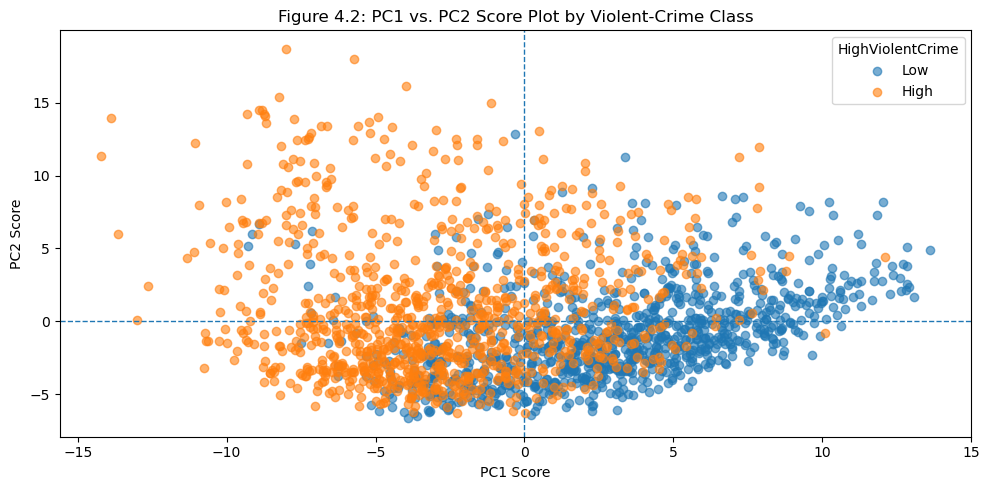

In [18]:

# Combine PCA scores with violent-crime class label
pca_plot_df = pca_scores_df[["PC1", "PC2"]].copy()
pca_plot_df["HighViolentCrime"] = df["HighViolentCrime"]

plt.figure(figsize=(10, 5))

for label in ["Low", "High"]:
    subset = pca_plot_df[pca_plot_df["HighViolentCrime"] == label]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        label=label
    )

plt.axhline(0, linewidth=1, linestyle="--")
plt.axvline(0, linewidth=1, linestyle="--")

plt.title("Figure 4.2: PC1 vs. PC2 Score Plot by Violent-Crime Class")
plt.xlabel("PC1 Score")
plt.ylabel("PC2 Score")
plt.legend(title="HighViolentCrime")
plt.tight_layout()
plt.show()

### 4.7 PCA Summary and Use in Later Sections

PCA reduced the 100 standardized predictors into a smaller set of orthogonal summaries. The first two PCs explain 42.0% of the total variance, the first five explain 64.5%, and the first eleven explain approximately 80.0%. Kaiser and parallel analysis suggest retaining about 13–14 PCs, so the later clustering and classification sections will use a retained PC-score matrix rather than all 100 original predictors.

For interpretation, only the first four PCs are labeled: PC1 captures economic advantage/family stability, PC2 captures immigration/language composition, PC3 captures household and occupancy structure, and PC4 captures residential stability/age composition. The PC1 score plot also shows clear alignment with `HighViolentCrime`, with high violent-crime communities concentrated more on the lower-PC1 side.

## 5. Factor Analysis: Latent Community Structure

### 5.1 Why Factor Analysis and How It Complements PCA

Factor analysis (FA) models the observed predictor correlations as products of a small number of **latent factors** plus variable-specific uniqueness terms. While PCA decomposes total variance into orthogonal components, FA explicitly separates **shared variance** (explained by latent factors) from **unique variance** (specific to each variable). This makes FA a natural complement to PCA when the goal is to identify interpretable latent community-level dimensions.

| Aspect | PCA | Factor Analysis |
|--------|-----|-----------------|
| Goal | Maximize total variance explained | Model shared covariance via latent factors |
| Model | Linear combinations of observed variables | Observed variables = factor loadings × latent factors + uniqueness |
| Rotation | Components are orthogonal by construction | Loadings can be rotated (varimax, promax) for interpretability |
| Uniqueness | Not separated | Each variable has an explicit uniqueness term |

**Workflow for this section:**

| Step | Task | Key Output |
|------|------|------------|
| 1 | Setup — same standardized predictor matrix as PCA | Correlation matrix, dimensions confirmed |
| 2 | Factor selection diagnostics — parallel analysis + RMSR | Narrow the candidate range |
| 3 | Compare candidate models — rotated loadings side by side | Choose the final factor count |
| 4 | Final model — rotated loading table and factor interpretation | Named latent dimensions |
| 5 | Factor scores by violent-crime class | Boxplots linking factors to the outcome |

### 5.2 Step 1: Setup

Factor analysis uses the same standardized predictor matrix from the PCA section (`X_scaled`), containing 100 predictor variables across 1,994 communities. The observed predictor correlation matrix is created here because factor selection and residual checks are based on how well the factor model reproduces this correlation structure.

In [19]:
# Factor analysis uses the same standardized predictor matrix from PCA
X_fa = X_scaled.copy()

# Observed predictor correlation matrix (used for diagnostics throughout)
R_observed = X_fa.corr()

# Setup summary
fa_setup_summary = pd.DataFrame({
    "Object": [
        "Standardized predictor matrix",
        "Observed correlation matrix"
    ],
    "Rows": [X_fa.shape[0], R_observed.shape[0]],
    "Columns": [X_fa.shape[1], R_observed.shape[1]]
})

fa_setup_summary

,Object,Rows,Columns
0,Standardized predictor matrix,1994,100
1,Observed correlation matrix,100,100


The factor analysis starts from the same 1,994 × 100 standardized predictor matrix used in PCA. The 100 × 100 observed correlation matrix will serve as the reference for all residual-fit checks below.

### 5.3 Step 2: Factor Selection Diagnostics

Two diagnostics are used to narrow the candidate range for the number of factors:

1. **Parallel analysis** — compares the observed eigenvalues of the correlation matrix against eigenvalues from randomly generated data of the same dimensions. Factors whose observed eigenvalues exceed the random reference contain more structure than noise. This provides an **upper bound** on the number of meaningful factors.

2. **Residual correlation RMSR** — for each candidate factor count, the factor model is fit and the model-implied correlation matrix is compared to the observed one. The root-mean-square of the off-diagonal residual correlations (RMSR) measures how much correlation structure remains unexplained. Lower RMSR indicates better fit.

Together, parallel analysis identifies how many factors are statistically distinguishable from noise, while RMSR shows where adding more factors stops meaningfully improving the fit.

In [20]:
from sklearn.decomposition import FactorAnalysis

# ── Parallel analysis ──
n_simulations = 100
n_obs, n_vars = X_fa.shape

observed_eigenvalues = np.linalg.eigvalsh(R_observed)[::-1]

random_eigenvalues = np.zeros((n_simulations, n_vars))
for i in range(n_simulations):
    random_data = np.random.normal(size=(n_obs, n_vars))
    random_corr = pd.DataFrame(random_data).corr()
    random_eigenvalues[i, :] = np.linalg.eigvalsh(random_corr)[::-1]

random_mean = random_eigenvalues.mean(axis=0)
random_95 = np.percentile(random_eigenvalues, 95, axis=0)

parallel_mean_factors = int((observed_eigenvalues > random_mean).sum())
parallel_95_factors = int((observed_eigenvalues > random_95).sum())

# ── RMSR across candidate factor counts ──
def compute_fa_rmsr(X_data, n_factors):
    """Fit a varimax-rotated FA model and return off-diagonal residual correlation RMSR."""
    fa = FactorAnalysis(n_components=n_factors, rotation="varimax", random_state=42)
    fa.fit(X_data)
    loadings = fa.components_.T
    R_hat = loadings @ loadings.T + np.diag(fa.noise_variance_)
    d = np.sqrt(np.diag(R_hat))
    R_hat_corr = R_hat / np.outer(d, d)
    residual = R_observed.values - R_hat_corr
    off_diag = residual[np.triu_indices_from(residual, k=1)]
    return np.sqrt(np.mean(off_diag ** 2))

candidate_range = range(2, 16)
rmsr_results = pd.DataFrame({
    "Factors": list(candidate_range),
    "RMSR": [compute_fa_rmsr(X_fa, m) for m in candidate_range]
})
rmsr_results["RMSR Improvement"] = rmsr_results["RMSR"].shift(1) - rmsr_results["RMSR"]

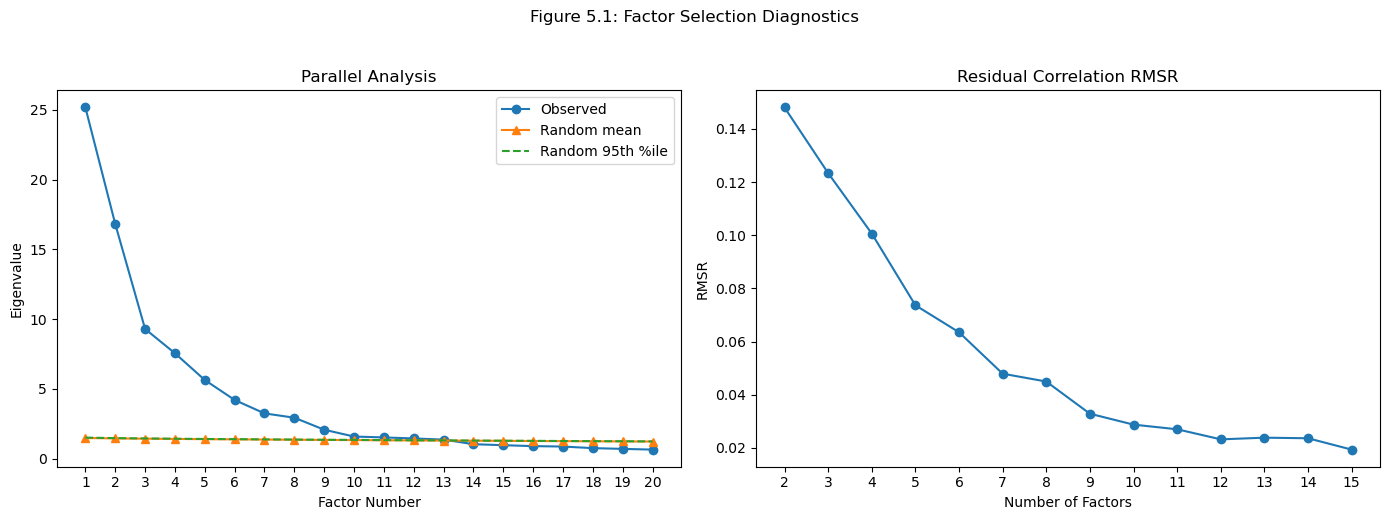

In [21]:
# ── Figure 5.1: Factor selection diagnostics (parallel analysis + RMSR) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Parallel analysis
max_plot = 20
factor_numbers = np.arange(1, max_plot + 1)
axes[0].plot(factor_numbers, observed_eigenvalues[:max_plot], marker="o", label="Observed")
axes[0].plot(factor_numbers, random_mean[:max_plot], marker="^", label="Random mean")
axes[0].plot(factor_numbers, random_95[:max_plot], linestyle="--", label="Random 95th %ile")
axes[0].set_title("Parallel Analysis")
axes[0].set_xlabel("Factor Number")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_xticks(factor_numbers)
axes[0].legend()

# Right: RMSR curve
axes[1].plot(rmsr_results["Factors"], rmsr_results["RMSR"], marker="o")
axes[1].set_title("Residual Correlation RMSR")
axes[1].set_xlabel("Number of Factors")
axes[1].set_ylabel("RMSR")
axes[1].set_xticks(list(candidate_range))

plt.suptitle("Figure 5.1: Factor Selection Diagnostics", y=1.03)
plt.tight_layout()
plt.show()

In [22]:
# ── Table 5.1: Diagnostic summary ──
diagnostic_summary = pd.DataFrame({
    "Criterion": [
        "Parallel analysis (observed > random mean)",
        "Parallel analysis (observed > random 95th percentile)"
    ],
    "Suggested Factors": [parallel_mean_factors, parallel_95_factors]
})

print("Table 5.1a: Parallel Analysis Summary")
display(diagnostic_summary)

print("\nTable 5.1b: RMSR by Factor Count")
display(rmsr_results.round(4))

Table 5.1a: Parallel Analysis Summary


,Criterion,Suggested Factors
0,Parallel analysis (observed > random mean),13
1,Parallel analysis (observed > random 95th percentile),13



Table 5.1b: RMSR by Factor Count


,Factors,RMSR,RMSR Improvement
0,2,0.1481,NaN
1,3,0.1234,0.0247
2,4,0.1007,0.0227
3,5,0.0737,0.0270
4,6,0.0635,0.0101
5,7,0.0479,0.0156
6,8,0.0450,0.0030
7,9,0.0329,0.0121
8,10,0.0288,0.0041
9,11,0.0270,0.0018


**Reading the diagnostics:**

- Parallel analysis suggests up to roughly 13 factors contain more structure than random noise. However, a 13-factor model would be difficult to interpret and would not provide a concise latent structure.
- The RMSR curve shows the sharpest improvements in the 4–7 factor range, with diminishing returns beyond about 7–8 factors.
- **Decision:** The candidate range for detailed comparison is narrowed to **7–10 factors** — enough to capture the main structure while remaining interpretable. The next step compares their rotated loading patterns side by side.

### 5.4 Final Model — Rotated Loadings and Factor Interpretation

The parallel analysis and RMSR diagnostics above indicate 7 factors as the best balance between interpretability and fit within the candidate range. With the 7-factor model selected, this step presents the full rotated loading table and assigns interpretive labels to each factor based on which variables load most strongly. These labels are **descriptive summaries**, not causal constructs.

In [23]:
from sklearn.decomposition import FactorAnalysis

# Fit the 7-factor varimax model directly
final_n_factors = 7
final_fa = FactorAnalysis(n_components=final_n_factors, rotation="varimax", random_state=0)
final_fa.fit(X_fa)

# Loading matrix (variables × factors)
final_loadings = pd.DataFrame(
    final_fa.components_.T,
    index=X_fa.columns,
    columns=[f"Factor{k+1}" for k in range(final_n_factors)]
)

# Factor scores (communities × factors)
final_scores = pd.DataFrame(
    final_fa.transform(X_fa),
    index=X_fa.index,
    columns=[f"Factor{k+1}" for k in range(final_n_factors)]
)

# Table 5.3: top 8 loadings per factor by absolute value
print(f"Table 5.3: Rotated Factor Loadings — {final_n_factors}-Factor Model (top 8 per factor)")
for col in final_loadings.columns:
    top = final_loadings[col].abs().nlargest(8).index
    print(f"\n{col}:")
    print(final_loadings.loc[top, col].round(3).to_string())


Table 5.3: Rotated Factor Loadings — 7-Factor Model (top 8 per factor)

Factor1:
PctRecImmig8           0.956
PctRecImmig5           0.954
PctRecImmig10          0.954
PctRecentImmig         0.939
PctForeignBorn         0.904
PctNotSpeakEnglWell    0.824
PctSpeakEnglOnly      -0.794
PctPersDenseHous       0.694

Factor2:
whitePerCap     -0.933
medFamInc       -0.933
perCapInc       -0.929
medIncome       -0.903
RentHighQ       -0.869
OwnOccHiQuart   -0.862
RentMedian      -0.860
MedRent         -0.860

Factor3:
population       0.985
numbUrban        0.981
NumUnderPov      0.929
HousVacant       0.887
NumIlleg         0.864
NumInShelters    0.806
LandArea         0.727
NumImmig         0.698

Factor4:
PersPerOccupHous      0.941
PersPerFam            0.932
householdsize         0.872
PersPerOwnOccHous     0.867
PctLargHouseOccup     0.807
PersPerRentOccHous    0.747
PctLargHouseFam       0.736
agePct65up           -0.510

Factor5:
agePct16t24        0.943
agePct12t29        0.847
agePc

**Table 5.4: Factor Interpretation Summary**

| Factor | Suggested Label | Key High-Loading Variables | Theme |
|--------|----------------|---------------------------|-------|
| Factor 1 | Immigration / Language Composition | `PctRecImmig8`, `PctRecImmig5`, `PctRecImmig10`, `PctRecentImmig`, `PctForeignBorn`, `PctNotSpeakEnglWell`, `PctSpeakEnglOnly` (−) | Captures variation in recent immigration, foreign-born population share, and English-language patterns. |
| Factor 2 | Income / Housing Value | `whitePerCap`, `medFamInc`, `perCapInc`, `medIncome`, `RentHighQ`, `OwnOccHiQuart`, `RentMedian`, `MedRent` | Captures shared variation in income levels and housing/rental values. The displayed signs are negative, but factor signs are arbitrary. |
| Factor 3 | Urban Size / Concentrated Disadvantage | `population`, `numbUrban`, `NumUnderPov`, `HousVacant`, `NumIlleg`, `NumInShelters`, `LandArea`, `NumImmig` | Captures larger urban communities with higher counts of poverty, vacancy, shelter population, and related aggregate disadvantage measures. |
| Factor 4 | Household Size / Occupancy | `PersPerOccupHous`, `PersPerFam`, `householdsize`, `PersPerOwnOccHous`, `PctLargHouseOccup`, `PersPerRentOccHous`, `PctLargHouseFam` | Captures household size, family size, and occupancy intensity. |
| Factor 5 | Youth / Young Adult Composition | `agePct16t24`, `agePct12t29`, `agePct12t21`, `MalePctNevMarr`, `PctEmplProfServ`, `PctImmigRecent` | Captures communities with larger youth and young-adult population shares. |
| Factor 6 | Family Structure / Community Composition | `PctKids2Par` (−), `PctFam2Par` (−), `PctIlleg`, `PctTeen2Par` (−), `PctYoungKids2Par` (−), `FemalePctDiv`, `racepctblack`, `racePctWhite` (−) | Captures variation in family structure and related community composition patterns. Sensitive demographic variables are treated only as aggregate descriptors. |
| Factor 7 | Older / Retirement and Residential Stability | `pctWSocSec`, `agePct65up`, `pctWWage` (−), `PctEmploy` (−), `PctSameHouse85`, `pctWRetire`, `MedYrHousBuilt` (−), `PctSameCity85` | Captures older, more retirement-oriented, and more residentially stable communities. |

### 5.5 Factor Scores by Violent-Crime Class

Factor scores are estimated for each community and compared across `HighViolentCrime` groups. This step assesses which latent dimensions are most strongly **associated with** above-median violent crime at the community level. Note that FA is unsupervised — the crime outcome was not used during model fitting — so any separation reflects genuine multivariate structure.

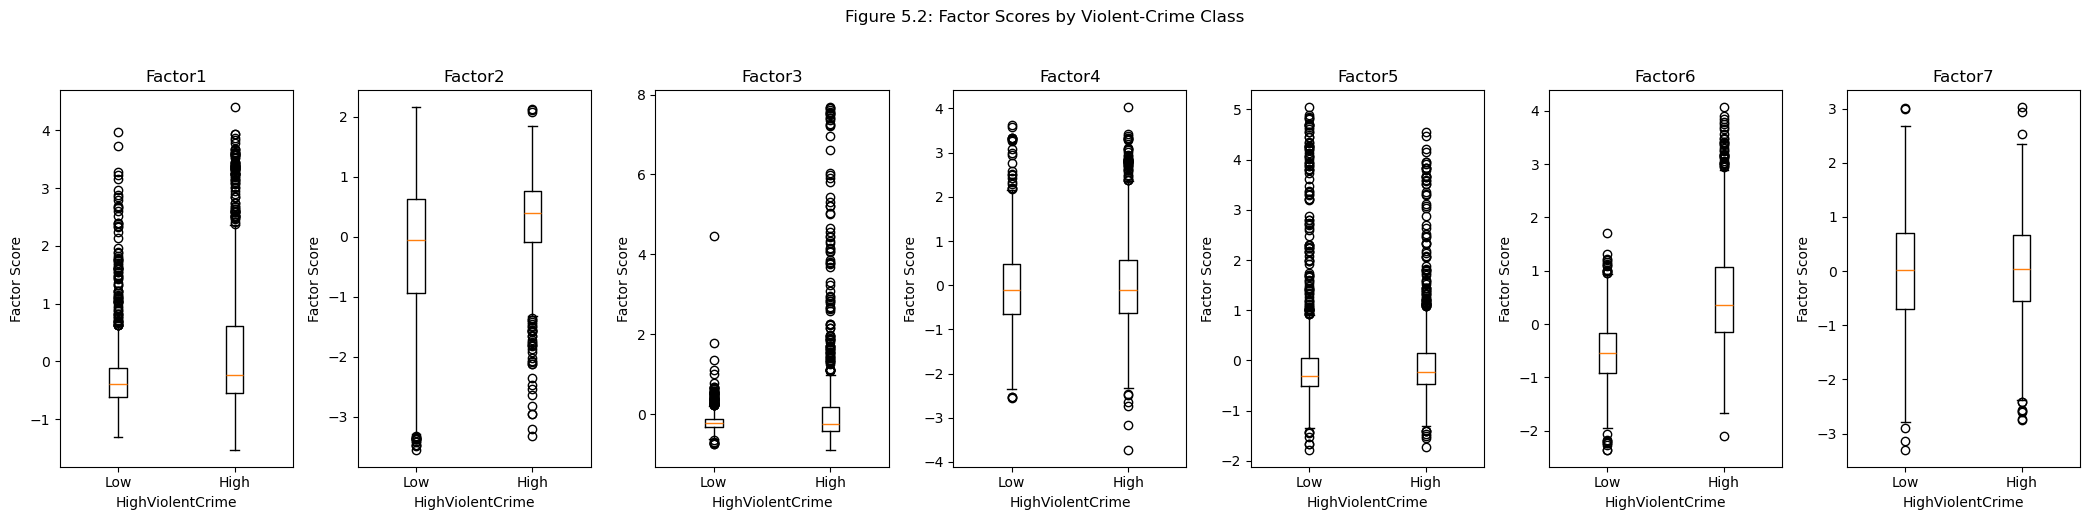

In [24]:

# Figure 5.2: Factor scores by HighViolentCrime
plot_df = final_scores.copy()
plot_df["HighViolentCrime"] = df["HighViolentCrime"].values

n_factors = final_scores.shape[1]
fig, axes = plt.subplots(1, n_factors, figsize=(3 * n_factors, 5), sharey=False)

for i, factor_col in enumerate(final_scores.columns):
    low_values = plot_df[plot_df["HighViolentCrime"] == "Low"][factor_col]
    high_values = plot_df[plot_df["HighViolentCrime"] == "High"][factor_col]
    
    axes[i].boxplot(
        [low_values, high_values],
        tick_labels=["Low", "High"]
    )
    
    axes[i].set_title(factor_col)
    axes[i].set_xlabel("HighViolentCrime")
    axes[i].set_ylabel("Factor Score")

plt.suptitle("Figure 5.2: Factor Scores by Violent-Crime Class", y=1.03)
plt.tight_layout()
plt.show()

In [25]:
factor_score_comparison = []

for factor in final_scores.columns:
    low_scores = plot_df[plot_df["HighViolentCrime"] == "Low"][factor]
    high_scores = plot_df[plot_df["HighViolentCrime"] == "High"][factor]
    
    factor_score_comparison.append({
        "Factor": factor,
        "Low Mean": low_scores.mean(),
        "High Mean": high_scores.mean(),
        "Mean Difference: High - Low": high_scores.mean() - low_scores.mean(),
        "Low Median": low_scores.median(),
        "High Median": high_scores.median(),
        "Median Difference: High - Low": high_scores.median() - low_scores.median()
    })

factor_score_comparison = pd.DataFrame(factor_score_comparison)

factor_score_comparison["Abs Mean Difference"] = (
    factor_score_comparison["Mean Difference: High - Low"].abs()
)

factor_score_comparison_sorted = factor_score_comparison.sort_values(
    "Abs Mean Difference",
    ascending=False
)

factor_score_comparison_sorted.round(3)

,Factor,Low Mean,High Mean,Mean Difference: High - Low,Low Median,High Median,Median Difference: High - Low,Abs Mean Difference
5,Factor6,-0.535,0.540,1.075,-0.536,0.355,0.891,1.075
1,Factor2,-0.264,0.267,0.531,-0.051,0.396,0.447,0.531
0,Factor1,-0.233,0.234,0.467,-0.387,-0.239,0.148,0.467
2,Factor3,-0.184,0.185,0.369,-0.231,-0.249,-0.017,0.369
6,Factor7,-0.026,0.026,0.052,0.019,0.039,0.020,0.052
3,Factor4,-0.023,0.024,0.047,-0.116,-0.112,0.004,0.047
4,Factor5,0.022,-0.022,-0.045,-0.303,-0.237,0.066,0.045


Figure 5.2 and the factor-score comparison table show that the strongest separation between low and high violent-crime communities occurs on **Factor 6**. High violent-crime communities have a mean Factor 6 score of 0.540, while low violent-crime communities have a mean score of -0.535, giving a mean difference of 1.075. Since Factor 6 represents family structure / community composition, this is the factor most strongly associated with `HighViolentCrime`.

The next largest differences occur for **Factor 2** and **Factor 1**. Factor 2 has a mean difference of 0.531 and represents the income / housing-value dimension, while Factor 1 has a mean difference of 0.467 and represents immigration / language composition. Factor 3, the urban size / concentrated-disadvantage factor, shows a smaller mean difference of 0.369. Factors 4, 5, and 7 show very small mean differences, suggesting weaker separation between low and high violent-crime communities along household-size, youth-composition, and older/retirement dimensions.

### 5.6 Factor Analysis Summary and Use in Later Sections

Factor analysis produced a 7-factor varimax solution from the 100 standardized predictors. The interpreted factors are immigration/language composition, income/housing value, urban size/concentrated disadvantage, household size/occupancy, youth/young-adult composition, family structure/community composition, and older/retirement/residential stability.

The strongest class separation appears for **Factor 6**, the family-structure/community-composition factor, with a mean score difference of **1.075** between high and low violent-crime communities. Smaller but still notable differences appear for **Factor 2** (income/housing value, difference = **0.531**), **Factor 1** (immigration/language composition, difference = **0.467**), and **Factor 3** (urban size/concentrated disadvantage, difference = **0.369**).

The factor scores will be used alongside PCA scores as alternative lower-dimensional inputs for clustering and classification. The factor labels are working interpretations of loading patterns, not causal explanations or fixed ground-truth categories.

## 6. Clustering: Community Profiles

Clustering is used to group communities with similar multivariate characteristics. Because the original predictor space contains 100 variables with substantial correlation, clustering is performed on retained PCA scores rather than the raw predictors. This lower-dimensional representation keeps the main shared structure while making distance-based clustering more stable and easier to interpret.

The clusters are interpreted as exploratory community profiles. They are not treated as ground-truth categories or causal groups.

### 6.1 Clustering Input and Distance Choice

The clustering input is the retained PCA score matrix. Specifically, the analysis uses the first PCs needed to reach approximately 80% cumulative variance explained. This gives a compact representation of the predictor space while preserving most of the multivariate variation.

Euclidean distance is used for clustering because both K-means and Ward hierarchical clustering are based on squared-distance geometry. The same PCA-score input is used for both methods so that the resulting cluster solutions are comparable.

In [26]:
# Clustering input setup: retained PCA scores

# Number of PCs needed to reach at least 80% cumulative variance
n_pcs_clustering = pcs_for_80

# Retained PCA score matrix for clustering
cluster_input = pca_scores_df.iloc[:, :n_pcs_clustering].copy()

# Summary table
cluster_input_summary = pd.DataFrame({
    "Input Representation": ["Retained PCA scores"],
    "Distance Geometry": ["Euclidean"],
    "Number of Observations": [cluster_input.shape[0]],
    "Number of Features": [cluster_input.shape[1]],
    "Selection Rule": ["Minimum PCs needed to reach 80% cumulative variance"],
    "Cumulative Variance Explained": [cumulative_variance[n_pcs_clustering - 1]]
})

cluster_input_summary.round(3)

,Input Representation,Distance Geometry,Number of Observations,Number of Features,Selection Rule,Cumulative Variance Explained
0,Retained PCA scores,Euclidean,1994,11,Minimum PCs needed to reach 80% cumulative variance,0.8


The clustering input consists of the first 11 PCA scores, which together explain approximately 80% of the total predictor variance. This reduces the original 100-dimensional predictor space to a compact representation while retaining most of the shared multivariate structure. The same retained PCA-score matrix is used for both K-means and hierarchical clustering, making the two hard-clustering methods directly comparable.

### 6.2 K-Means Clustering

K-means clustering partitions communities into a fixed number of clusters, \(K\), by minimizing within-cluster variation. The analysis fits K-means models over a range of possible \(K\) values and evaluates them using two diagnostics:

1. **Elbow plot:** shows how within-cluster sum of squares decreases as \(K\) increases.
2. **Silhouette score:** measures how well-separated the clusters are on average.

The final value of \(K\) is chosen by balancing compactness, separation, and interpretability.

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import os

os.environ["OMP_NUM_THREADS"] = "8"
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

# Candidate K values
k_values = range(2, 21)

kmeans_results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    cluster_labels = kmeans.fit_predict(cluster_input)
    
    kmeans_results.append({
        "K": k,
        "Within-Cluster Sum of Squares": kmeans.inertia_,
        "Silhouette Score": silhouette_score(cluster_input, cluster_labels)
    })

kmeans_results_table = pd.DataFrame(kmeans_results)

kmeans_results_table.round(3)

,K,Within-Cluster Sum of Squares,Silhouette Score
0,2,124926.633,0.208
1,3,105420.347,0.229
2,4,95894.843,0.160
3,5,86670.698,0.177
4,6,78423.867,0.197
5,7,72795.052,0.198
6,8,68365.195,0.175
7,9,64773.500,0.174
8,10,61563.593,0.188
9,11,59244.060,0.177


### 6.3 Choosing the Number of K-Means Clusters

The elbow and silhouette plots are used together to select the number of clusters. A good choice of \(K\) should reduce within-cluster variation substantially without creating too many small or hard-to-interpret clusters. The silhouette score provides an additional check by measuring whether communities are closer to their own cluster than to other clusters.

[Insert Figure 6.1: K-Means Elbow Plot]

[Insert Figure 6.2: Average Silhouette Score]

[Write selected K and justification here.]

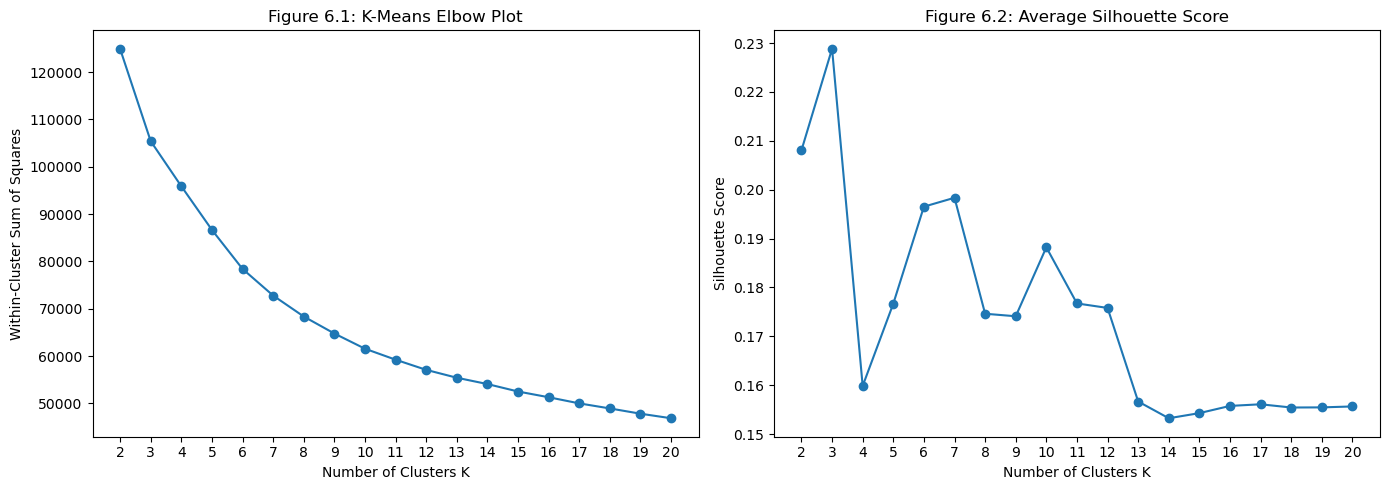

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Figure 6.1: Elbow plot
axes[0].plot(
    kmeans_results_table["K"],
    kmeans_results_table["Within-Cluster Sum of Squares"],
    marker="o"
)

axes[0].set_title("Figure 6.1: K-Means Elbow Plot")
axes[0].set_xlabel("Number of Clusters K")
axes[0].set_ylabel("Within-Cluster Sum of Squares")
axes[0].set_xticks(kmeans_results_table["K"])

# Figure 6.2: Silhouette plot
axes[1].plot(
    kmeans_results_table["K"],
    kmeans_results_table["Silhouette Score"],
    marker="o"
)

axes[1].set_title("Figure 6.2: Average Silhouette Score")
axes[1].set_xlabel("Number of Clusters K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(kmeans_results_table["K"])

plt.tight_layout()
plt.show()

Figures 7.1 and 7.2 evaluate K-means clustering across \(K = 2\) through \(K = 20\). The within-cluster sum of squares decreases steadily as \(K\) increases, but there is no strong later elbow that clearly supports a larger number of clusters. The silhouette score is highest at \(K = 3\), indicating that the three-cluster solution has the best average separation among the tested values.

Based on these diagnostics, the final K-means model uses **K = 3**. Because the silhouette scores are modest overall, the clusters are interpreted as broad exploratory community profiles rather than sharply separated natural groups.

### 6.4 Final K-Means Cluster Profiles

After selecting \(K\), the final K-means model is fit using the retained PCA scores. Each community is assigned to one cluster. The resulting clusters are profiled using:

- number of communities in each cluster,
- mean values of selected PC scores,
- mean `ViolentCrimesPerPop`,
- proportion of communities labeled `HighViolentCrime`.

This profile table is used to describe each cluster as a community type based on its multivariate characteristics and crime outcome summaries.

[Insert Table 6.1: K-Means Cluster Profile Table]

In [29]:

# Final K-means model
selected_k = 3

final_kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=20
)

kmeans_labels = final_kmeans.fit_predict(cluster_input)

# Create clustering results dataframe
kmeans_cluster_df = pca_scores_df.copy()
kmeans_cluster_df["KMeans Cluster"] = kmeans_labels
kmeans_cluster_df["ViolentCrimesPerPop"] = df["ViolentCrimesPerPop"].values
kmeans_cluster_df["HighViolentCrime"] = df["HighViolentCrime"].values

# Convert High/Low label to numeric indicator for cluster summaries
kmeans_cluster_df["HighViolentCrime Indicator"] = (
    kmeans_cluster_df["HighViolentCrime"] == "High"
).astype(int)

# Cluster profile table using first 4 PCs for interpretation
pc_profile_cols = ["PC1", "PC2", "PC3", "PC4"]

kmeans_profile_table = (
    kmeans_cluster_df
    .groupby("KMeans Cluster")
    .agg(
        Number_of_Communities=("KMeans Cluster", "size"),
        Mean_ViolentCrimesPerPop=("ViolentCrimesPerPop", "mean"),
        Proportion_HighViolentCrime=("HighViolentCrime Indicator", "mean"),
        Mean_PC1=("PC1", "mean"),
        Mean_PC2=("PC2", "mean"),
        Mean_PC3=("PC3", "mean"),
        Mean_PC4=("PC4", "mean")
    )
    .reset_index()
)

# Sort clusters from lowest to highest average violent crime for easier interpretation
kmeans_profile_table = kmeans_profile_table.sort_values(
    "Mean_ViolentCrimesPerPop"
).reset_index(drop=True)

kmeans_profile_table.round(3)

,KMeans Cluster,Number_of_Communities,Mean_ViolentCrimesPerPop,Proportion_HighViolentCrime,Mean_PC1,Mean_PC2,Mean_PC3,Mean_PC4
0,1,793,0.105,0.206,5.035,0.215,0.237,0.270
1,0,979,0.295,0.641,-3.024,-1.996,-0.571,-0.513
2,2,222,0.464,0.910,-4.649,8.034,1.673,1.297


Table 6.1 shows clear differences in violent-crime outcomes across the three K-means clusters. Cluster 1 has the lowest average `ViolentCrimesPerPop` at 0.105 and only 20.6% of communities are classified as high violent-crime communities. This cluster has a strongly positive mean PC1 score, suggesting higher economic advantage and family stability based on the earlier PCA interpretation.

Cluster 0 has an intermediate profile, with mean `ViolentCrimesPerPop` of 0.295 and 64.1% high violent-crime communities. Its negative PC1 score suggests lower economic advantage/family stability than Cluster 1, while its negative PC2 score indicates a different immigration/language composition profile than the high-crime cluster.

Cluster 2 has the highest average `ViolentCrimesPerPop` at 0.464 and 91.0% of communities are classified as high violent-crime communities. This cluster has a strongly negative PC1 score and a very high positive PC2 score, suggesting that it combines lower economic advantage/family stability with a distinct immigration/language composition pattern. Because clustering is unsupervised, these differences are interpreted as descriptive associations between community profiles and crime outcomes, not causal effects.

### 6.5 K-Means Cluster Visualization

The final K-means clusters are visualized in the PC1–PC2 score space. This plot shows how the cluster assignments relate to the first two PCA dimensions and whether clusters occupy distinct regions of the low-dimensional predictor space.

[Insert Figure 6.3: K-Means Clusters in PC Space]

[Write cluster interpretation here.]

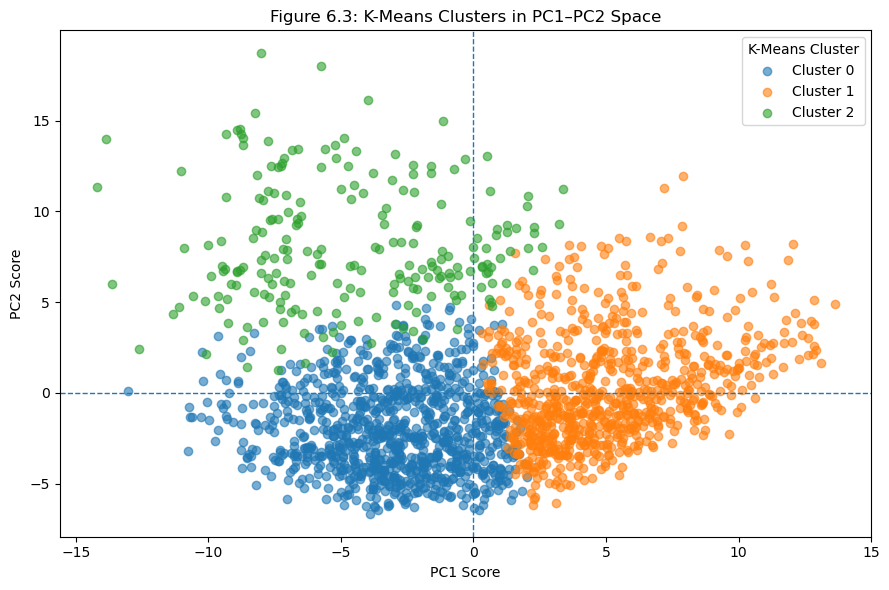

In [30]:
# PC-space visualization dataframe
kmeans_plot_df = kmeans_cluster_df[["PC1", "PC2", "KMeans Cluster"]].copy()

plt.figure(figsize=(9, 6))

for cluster in sorted(kmeans_plot_df["KMeans Cluster"].unique()):
    subset = kmeans_plot_df[kmeans_plot_df["KMeans Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        label=f"Cluster {cluster}"
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Figure 6.3: K-Means Clusters in PC1–PC2 Space")
plt.xlabel("PC1 Score")
plt.ylabel("PC2 Score")
plt.legend(title="K-Means Cluster")
plt.tight_layout()
plt.show()

Figure 6.3 shows the final K-means cluster assignments in PC1–PC2 space. The clusters separate mainly along the first two PCA dimensions. Cluster 1 is concentrated on the positive side of PC1, matching the lower-crime profile from Table 6.1. Cluster 0 occupies the lower PC2 and mostly negative PC1 region, corresponding to the intermediate-crime profile. Cluster 2 is concentrated at high positive PC2 values and has the highest mean violent-crime rate and highest proportion of high violent-crime communities.

The clusters are not perfectly separated, which is consistent with the modest silhouette scores. They should therefore be interpreted as broad exploratory community profiles rather than sharply defined natural groups.

### 6.6 Clustering Summary

K-means clustering identified three broad community profiles in the retained PCA space, selected at \(K = 3\) based on the highest average silhouette score.

The lowest-crime cluster had positive mean PC1 scores (higher economic advantage and family stability). The highest-crime cluster had strongly negative PC1 scores and a distinct immigration/language composition pattern (elevated PC2). The intermediate cluster fell between these extremes on both dimensions.

These clusters are exploratory summaries, not ground-truth community types. Differences in average `ViolentCrimesPerPop` and `HighViolentCrime` proportions across clusters describe associations between multivariate community profiles and violent-crime outcomes, not causal effects.

## 7. Classification: Predicting `HighViolentCrime`

This section uses supervised classification to predict the binary outcome `HighViolentCrime`. Unlike the earlier unsupervised methods, the models in this section use the outcome label during fitting.

The goal is to compare predictive performance across three input representations: the original standardized predictors, retained PCA scores, and factor scores. Logistic regression is fit on all three inputs. LDA is fit on the PCA and factor scores, since these lower-dimensional inputs reduce collinearity and make the covariance-based classification step more stable.

All models are evaluated using the same stratified 70/30 train-test split, producing 1,395 training observations and 599 test observations. Model performance is compared using accuracy, sensitivity, specificity, and ROC-AUC.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Binary outcome
y = (df["HighViolentCrime"] == "High").astype(int)

# Input 1: original standardized predictors
X_original = X_scaled.copy()

# Input 2: retained PCA scores
X_pca_classification = pca_scores_df.iloc[:, :pcs_for_80].copy()

# Input 3: factor scores from final factor model
X_factor_classification = final_scores.copy()

# Train/test split using same indices for all inputs
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_original_train = X_original.loc[train_idx]
X_original_test = X_original.loc[test_idx]

X_pca_train = X_pca_classification.loc[train_idx]
X_pca_test = X_pca_classification.loc[test_idx]

X_factor_train = X_factor_classification.loc[train_idx]
X_factor_test = X_factor_classification.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

classification_setup = pd.DataFrame({
    "Input": [
        "Original standardized predictors",
        "Retained PCA scores",
        "Factor scores"
    ],
    "Train Rows": [
        X_original_train.shape[0],
        X_pca_train.shape[0],
        X_factor_train.shape[0]
    ],
    "Test Rows": [
        X_original_test.shape[0],
        X_pca_test.shape[0],
        X_factor_test.shape[0]
    ],
    "Number of Features": [
        X_original_train.shape[1],
        X_pca_train.shape[1],
        X_factor_train.shape[1]
    ]
})

classification_setup

,Input,Train Rows,Test Rows,Number of Features
0,Original standardized predictors,1395,599,100
1,Retained PCA scores,1395,599,11
2,Factor scores,1395,599,7


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

def evaluate_classifier(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    accuracy = accuracy_score(y_test, y_pred)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_test, y_prob)
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "ROC-AUC": auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Fitted Model": model,
        "Predicted Probabilities": y_prob
    }

models_to_evaluate = [
    (
        "Logistic Regression: Original Predictors",
        LogisticRegression(max_iter=5000),
        X_original_train,
        X_original_test
    ),
    (
        "Logistic Regression: PCA Scores",
        LogisticRegression(max_iter=5000),
        X_pca_train,
        X_pca_test
    ),
    (
        "Logistic Regression: Factor Scores",
        LogisticRegression(max_iter=5000),
        X_factor_train,
        X_factor_test
    ),
    (
        "LDA: PCA Scores",
        LinearDiscriminantAnalysis(),
        X_pca_train,
        X_pca_test
    ),
    (
        "LDA: Factor Scores",
        LinearDiscriminantAnalysis(),
        X_factor_train,
        X_factor_test
    )
]

classification_results = []

for model_name, model, X_train_model, X_test_model in models_to_evaluate:
    result = evaluate_classifier(
        model_name,
        model,
        X_train_model,
        X_test_model,
        y_train,
        y_test
    )
    classification_results.append(result)

classification_results_table = pd.DataFrame(classification_results).drop(
    columns=["Fitted Model", "Predicted Probabilities"]
)

classification_results_table[
    ["Model", "Accuracy", "Sensitivity", "Specificity", "ROC-AUC"]
].round(3)

,Model,Accuracy,Sensitivity,Specificity,ROC-AUC
0,Logistic Regression: Original Predictors,0.846,0.822,0.870,0.912
1,Logistic Regression: PCA Scores,0.830,0.826,0.834,0.912
2,Logistic Regression: Factor Scores,0.835,0.832,0.837,0.913
3,LDA: PCA Scores,0.825,0.799,0.850,0.905
4,LDA: Factor Scores,0.825,0.805,0.844,0.906


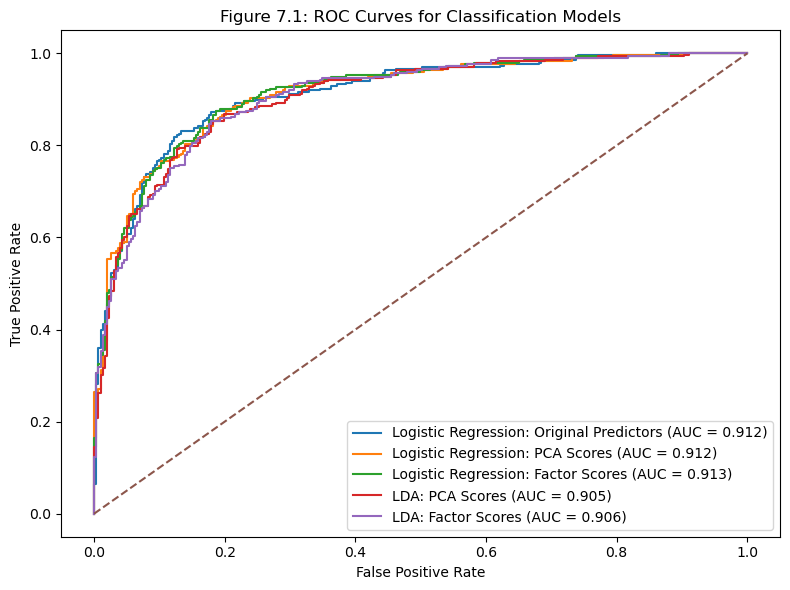

In [33]:

plt.figure(figsize=(8, 6))

for result in classification_results:
    fpr, tpr, thresholds = roc_curve(
        y_test,
        result["Predicted Probabilities"]
    )
    
    plt.plot(
        fpr,
        tpr,
        label=f'{result["Model"]} (AUC = {result["ROC-AUC"]:.3f})'
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Figure 7.1: ROC Curves for Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Select best model by ROC-AUC
best_result = max(classification_results, key=lambda x: x["ROC-AUC"])

best_confusion_matrix = pd.DataFrame(
    [[best_result["TN"], best_result["FP"]],
     [best_result["FN"], best_result["TP"]]],
    index=["Actual Low", "Actual High"],
    columns=["Predicted Low", "Predicted High"]
)

print("Best model:", best_result["Model"])
best_confusion_matrix

Best model: Logistic Regression: Factor Scores


,Predicted Low,Predicted High
Actual Low,252,49
Actual High,50,248


Table 7.1 compares five supervised classification models using the same stratified 70/30 train-test split. All metrics are reported out-of-sample on the held-out test set of 599 observations. Overall performance is very similar across models, with ROC-AUC values ranging from 0.905 to 0.913. This suggests that the main predictive information is retained across the original standardized predictors, PCA scores, and factor scores.

The **highest accuracy** is achieved by **Logistic Regression using the original standardized predictors**, with accuracy = 0.846, sensitivity = 0.822, specificity = 0.870, and ROC-AUC = 0.912. The best model by ROC-AUC is **Logistic Regression using Factor Scores**, with ROC-AUC = 0.913, accuracy = 0.835, sensitivity = 0.832, and specificity = 0.837. Because the difference in ROC-AUC is very small, the original-predictor logistic model has the strongest default-threshold accuracy, while the factor-score logistic model has the strongest threshold-independent discrimination.

Logistic regression on PCA scores performs nearly identically to the original-predictor model in ROC-AUC, showing that the retained PCA scores preserve most of the predictive structure in the original predictors. LDA performs slightly worse than logistic regression, with ROC-AUC values of 0.905 for PCA scores and 0.906 for factor scores. 

## 8. Regularization and High-Dimensional Concerns

Regularization is used to address instability from fitting logistic regression with many correlated predictors. This section fits ridge, lasso, and elastic net logistic regression on the original standardized predictor matrix. Unlike the lower-dimensional PCA and factor-score models, these models use all 100 predictors but control model complexity through coefficient shrinkage.

Regularization strength is selected using 5-fold cross-validation within the training set. Final model performance is evaluated out-of-sample on the same held-out 30% test set used in Section 7.

In [35]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import pandas as pd
import numpy as np

# Regularized logistic regression uses the original standardized predictors
X_reg_train = X_original_train.copy()
X_reg_test = X_original_test.copy()

# C is inverse regularization strength:
# smaller C = stronger regularization
C_values = np.logspace(-4, 4, 50)

regularization_setup = pd.DataFrame({
    "Input": ["Original standardized predictors"],
    "Train Rows": [X_reg_train.shape[0]],
    "Test Rows": [X_reg_test.shape[0]],
    "Number of Features": [X_reg_train.shape[1]],
    "C Values Tested": [len(C_values)],
    "Cross-Validation Folds": [5]
})

regularization_setup

,Input,Train Rows,Test Rows,Number of Features,C Values Tested,Cross-Validation Folds
0,Original standardized predictors,1395,599,100,50,5


In [36]:
# Ridge logistic regression: L2 penalty
ridge_cv = LogisticRegressionCV(
    Cs=C_values,
    cv=5,
    penalty="l2",
    solver="lbfgs",
    scoring="roc_auc",
    max_iter=5000,
    random_state=42
)

# Lasso logistic regression: L1 penalty
lasso_cv = LogisticRegressionCV(
    Cs=C_values,
    cv=5,
    penalty="l1",
    solver="saga",
    scoring="roc_auc",
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

# Elastic net logistic regression: combined L1/L2 penalty
elastic_net_cv = LogisticRegressionCV(
    Cs=C_values,
    cv=5,
    penalty="elasticnet",
    solver="saga",
    l1_ratios=[0.25, 0.50, 0.75],
    scoring="roc_auc",
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

regularized_models = {
    "Ridge Logistic Regression": ridge_cv,
    "Lasso Logistic Regression": lasso_cv,
    "Elastic Net Logistic Regression": elastic_net_cv
}

for model in regularized_models.values():
    model.fit(X_reg_train, y_train)

Ridge, lasso, and elastic net logistic regression are fit using cross-validation. Ridge shrinks all coefficients, lasso can set coefficients exactly to zero, and elastic net combines both forms of shrinkage.

In [37]:
def evaluate_regularized_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    coef = model.coef_.ravel()
    nonzero_count = (coef != 0).sum()
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Selected C": model.C_[0],
        "Nonzero Coefficients": nonzero_count
    }

regularized_results = []

for model_name, model in regularized_models.items():
    regularized_results.append(
        evaluate_regularized_model(
            model_name,
            model,
            X_reg_test,
            y_test
        )
    )

regularized_results_table = pd.DataFrame(regularized_results)

regularized_results_table.round(3)

,Model,Accuracy,Sensitivity,Specificity,ROC-AUC,Selected C,Nonzero Coefficients
0,Ridge Logistic Regression,0.841,0.822,0.860,0.915,0.041,100
1,Lasso Logistic Regression,0.848,0.822,0.874,0.913,0.184,47
2,Elastic Net Logistic Regression,0.838,0.819,0.857,0.914,0.060,44


Regularization provides a modest predictive improvement over the unpenalized logistic regression model, but the gains are small. Ridge has the highest ROC-AUC at 0.915, compared with 0.912 for the unpenalized original-predictor logistic model. Lasso has the highest accuracy at 0.848, compared with 0.846 for the unpenalized model.

The main benefit of regularization is therefore not a large increase in predictive performance, but improved stability and parsimony. Lasso retains 47 of the 100 predictors and elastic net retains 44, while achieving performance similar to or slightly better than the full unpenalized model. This suggests that much of the predictive signal can be captured with a smaller regularized subset of predictors.

In [38]:
def coefficient_table(model, feature_names, model_name):
    coef = model.coef_.ravel()
    
    coef_df = pd.DataFrame({
        "Variable": feature_names,
        "Coefficient": coef,
        "Abs Coefficient": np.abs(coef),
        "Model": model_name
    })
    
    coef_df = coef_df[coef_df["Coefficient"] != 0]
    coef_df = coef_df.sort_values("Abs Coefficient", ascending=False)
    
    return coef_df

lasso_coef_table = coefficient_table(
    lasso_cv,
    X_reg_train.columns,
    "Lasso Logistic Regression"
)

elastic_net_coef_table = coefficient_table(
    elastic_net_cv,
    X_reg_train.columns,
    "Elastic Net Logistic Regression"
)

lasso_coef_table.round(3).head(20)

,Variable,Coefficient,Abs Coefficient,Model
15,pctWInvInc,-0.864,0.864,Lasso Logistic Regression
2,racepctblack,0.772,0.772,Lasso Logistic Regression
44,PctKids2Par,-0.445,0.445,Lasso Logistic Regression
50,PctIlleg,0.432,0.432,Lasso Logistic Regression
68,PctPersDenseHous,0.341,0.341,Lasso Logistic Regression
94,PctSameCity85,0.299,0.299,Lasso Logistic Regression
75,PctVacMore6Mos,-0.282,0.282,Lasso Logistic Regression
90,NumStreet,0.252,0.252,Lasso Logistic Regression
38,MalePctDivorce,0.236,0.236,Lasso Logistic Regression
99,LemasPctOfficDrugUn,0.204,0.204,Lasso Logistic Regression


Table 8.1 reports the largest nonzero coefficients from the lasso model, which retained 47 of the 100 standardized predictors. Positive coefficients indicate higher predicted probability of `HighViolentCrime`, while negative coefficients indicate lower predicted probability.

The selected variables include investment income, racial composition, family structure, dense housing, residential stability, vacancy, divorce, and law-enforcement/drug-unit measures. Race variables such as `racepctblack` and `racePctWhite` are predictive within this fitted model, but this should not be interpreted causally.

These coefficients represent predictive associations only. Because the predictors are highly correlated, lasso may select one variable from a correlated group while shrinking related variables to zero.

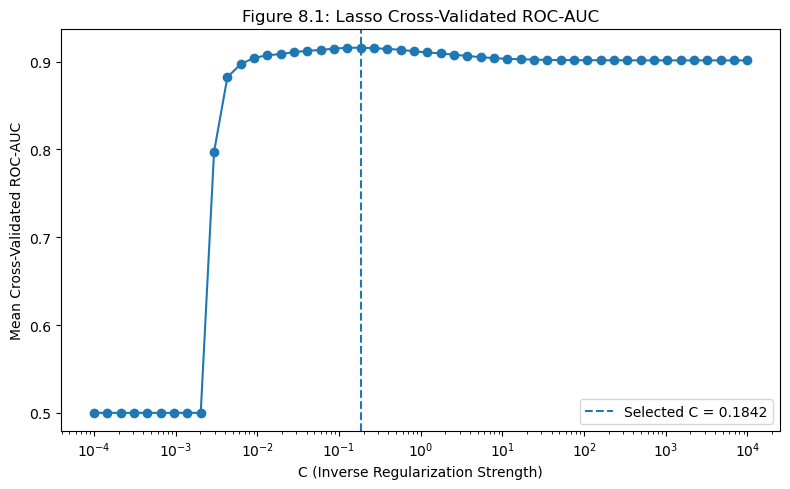

In [39]:

# Mean cross-validated ROC-AUC for lasso across C values
lasso_mean_auc = lasso_cv.scores_[1].mean(axis=0)

plt.figure(figsize=(8, 5))

plt.plot(
    lasso_cv.Cs_,
    lasso_mean_auc,
    marker="o"
)

plt.xscale("log")
plt.axvline(
    lasso_cv.C_[0],
    linestyle="--",
    label=f"Selected C = {lasso_cv.C_[0]:.4f}"
)

plt.title("Figure 8.1: Lasso Cross-Validated ROC-AUC")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Mean Cross-Validated ROC-AUC")
plt.legend()
plt.tight_layout()
plt.show()

Figure 8.1 shows the lasso cross-validated ROC-AUC across values of \(C\), where smaller \(C\) means stronger regularization. When \(C\) is very small, the penalty is too strong and the model has little predictive ability. As \(C\) increases, ROC-AUC improves sharply, then levels off.

Cross-validation selects \(C = 0.184\), which balances predictive performance and sparsity. Larger values of \(C\) weaken the penalty and allow more coefficients into the model, but they do not meaningfully improve cross-validated ROC-AUC.

---
## 9. Model Comparison and Synthesis

### Purpose

Synthesize the results from all preceding sections into a unified summary.

### Table 9.1: Summary of All Methods

| Method | Course Concept | Input | Output | Main Insight | Limitation |
|--------|---------------|-------|--------|-------------|------------|
| PCA | Dimension reduction | Standardized predictors | Principal components | PC1 (economic advantage/family stability) captures 28% of variance; first 11 PCs retain 80% | Linear, orthogonal; interpretations are post-hoc |
| Factor Analysis | Latent variable modeling | Standardized predictors | Latent factor scores | 7 varimax factors; Factor 6 (family structure) shows largest high/low crime mean difference (1.075) | Factor count and rotation are analytic choices |
| K-Means Clustering | Unsupervised clustering | Retained PCA scores | Hard cluster labels | Three profiles ordered by crime level along PC1 | Hard assignments; sensitive to K choice |
| Logistic Regression | Classification | Original predictors, PCA scores, or factor scores | Predicted class and probabilities | ROC-AUC 0.912–0.913 across all input representations | Unstable coefficients with correlated predictors |
| LDA | Classification | PCA scores or factor scores | Predicted class | ROC-AUC 0.905–0.906; slightly below logistic regression | Assumes equal within-class covariance |
| Ridge / Lasso / Elastic Net | Regularized classification | Standardized predictors | Predicted class and selected variables | Ridge AUC = 0.915; Lasso retains 47 of 100 predictors with near-identical accuracy | Coefficients not causally interpretable |

### Synthesis

**What multivariate structures appear repeatedly.** Both PCA and factor analysis identify the same dominant themes: economic disadvantage, family structure, and housing instability. In PCA these load onto PC1; in factor analysis they correspond to Factor 6 (family structure) and Factor 2 (income/housing value). The consistency between two independent dimension-reduction approaches confirms these are the primary axes of variation in this dataset.

**Do PCA/factor scores separate high vs. low violent-crime communities.** Yes. High violent-crime communities concentrate at the lower end of PC1. Factor 6 shows the largest mean difference (1.075) between the two outcome classes; Factor 2 and Factor 3 also show notable differences (0.531 and 0.369).

**Do clusters correspond to different average crime levels.** Yes. K-means at K = 3 identifies three profiles following a clear low-to-high crime gradient along PC1, directly connecting the unsupervised structure from PCA to the outcome.

**Which prediction approach performs best.** ROC-AUC ranges from 0.905 to 0.915 across all models. Dimension reduction does not degrade performance: logistic regression on factor scores achieves AUC = 0.913 with only 7 inputs versus 100. Ridge achieves the best AUC (0.915); Lasso matches it in accuracy while retaining only 47 predictors.

**Are conclusions stable across methods.** Yes. Every method identifies concentrated socioeconomic disadvantage and family instability as the primary community-level correlates of violent crime.

---
## 10. Limitations and Ethical Considerations

### Purpose

Acknowledge the important limitations of the data, methods, and interpretations. This section is critical for responsible reporting.

### Limitations

1. **Observational data, not causal.** All results describe statistical associations and predictive patterns. No causal claims can be made. Phrases such as "X causes Y" or "X leads to Y" are inappropriate.

2. **Ecological (aggregate) data.** Each observation is a community, not an individual. Community-level associations do not imply individual-level relationships (ecological fallacy). For example, a community-level correlation between poverty rate and crime rate does not mean that individuals in poverty commit more crimes.

3. **Measurement and reporting bias.** Crime data reflects reported and recorded crimes, not all crimes committed. Policing practices, reporting rates, and community trust in law enforcement vary across communities and can systematically bias crime statistics.

4. **Temporal mismatch.** The predictor variables come from 1990 (Census and LEMAS), while the crime data come from 1995 (FBI UCR). Changes between 1990 and 1995 are not captured, and the temporal gap introduces potential confounding.

5. **Sensitive demographic variables.** The dataset contains variables related to race, ethnicity, and immigration. These variables may be statistically correlated with crime rates at the community level due to systemic factors (e.g., historical segregation, differential access to resources, policing practices). **These correlations must not be interpreted as implying that any racial, ethnic, or immigrant group is inherently more prone to crime.** Careful, contextualized language is essential.

6. **Multicollinearity.** Many predictors are highly correlated. This makes individual regression coefficients unstable and difficult to interpret. Dimension reduction (PCA, factor analysis) and regularization mitigate this but do not eliminate interpretation challenges.

7. **Unsupervised results are model-dependent.** Clusters and GMM components depend on the number of groups chosen, the input features, and the algorithm. They are useful summaries but not ground-truth categories.

8. **Missing data treatment.** Dropping variables with >20% missingness and median-imputing the rest are pragmatic choices. They may introduce bias if missingness is not random.

9. **Generalizability.** Results are specific to this dataset and time period (early-to-mid 1990s U.S. communities). They may not generalize to other countries, time periods, or levels of aggregation.

### Ethical Framing Reminder

Throughout the report, all findings should be presented as aggregate community-level statistical patterns and predictive associations. Avoid language that attributes crime to demographic identity. Use phrases such as:

- "associated with"
- "predictive of"
- "correlated with"
- "communities characterized by higher levels of X tend to also have higher levels of Y"

Never use:

- "causes"
- "leads to"
- "results in"
- "is responsible for"

---
## 11. Conclusion

This project applied six multivariate methods to the Communities and Crime dataset to study community-level patterns associated with violent crime and to predict `HighViolentCrime`.

**Multivariate structure.** PCA and factor analysis both identify economic disadvantage, family structure, and housing instability as the dominant axes of community variation. PC1 alone captures 28% of the total variance across 100 predictors and is the most discriminating dimension for the crime outcome. Factor analysis confirms this: Factor 6 (family structure) shows the largest mean score difference between high and low violent-crime communities (1.075).

**Community profiles.** K-means at K = 3 identifies three community profiles forming a clear low-to-high crime gradient along PC1, connecting the structure discovered by PCA directly to the outcome.

**Prediction.** All classifiers achieve ROC-AUC between 0.905 and 0.915. Logistic regression on factor scores matches the full-predictor model (AUC = 0.913) using only 7 inputs. Ridge achieves the best AUC (0.915); Lasso achieves near-identical accuracy while retaining only 47 of 100 predictors.

**Limitations.** All results are observational, aggregate, and specific to this historical dataset (1990–1995). Demographic variables that appear in cluster profiles or lasso coefficients reflect systemic socioeconomic patterns and should not be interpreted as causal explanations for crime.

All methods converge on the same conclusion: concentrated socioeconomic disadvantage and family instability are the primary community-level correlates of violent crime in this dataset.